# Stochastic Volatility and Option Pricing Engine

### Introduction

Financial derivatives play a central role in modern financial markets, where accurate pricing and risk management are fundamental for traders, portfolio managers and quantitative analysts. Although the Black–Scholes model revolutionized option pricing by providing a closed-form analytical solution, its simplifying assumptions, particularly constant volatility, fail to capture many characteristics observed in real markets, such as volatility smiles, skewness, and stochastic dynamics.

This project presents a comprehensive Option Pricing & Stochastic Volatility Engine developed entirely in Python. Its objective is to implement, compare, and visualize a broad range of quantitative models used in modern derivatives pricing, from classical analytical solutions to advanced stochastic volatility frameworks.

The project combines mathematical theory, numerical methods, calibration techniques, and interactive visualizations into a single educational and practical platform. Rather than focusing on a single pricing methodology, it provides a unified environment where different models can be studied, compared, and evaluated under consistent assumptions.

The implemented models include:
- Black-Scholes-Merton
- Cox-Ross-Rubinstein Binomial Tree
- Monte Carlo Simulation
- Implied Volatility Estimation
- Volatility Surface Construction
- Local Volatility Models
- Heston Stochastic Volatility Model
- SABR Model
- Greeks Computation
- Option Strategy Analysis
- Calibration Techniques
- Interactive Streamlit Dashboard

Beyond pricing European options, the project aims to provide an intuitive understanding of how different assumptions affect derivative valuation while demonstrating practical implementation techniques commonly used in quantitative finance.

This repository is intended as both a learning resource and a portfolio project that showcases quantitative modeling, numerical methods, financial engineering, and Python development.

In [129]:
import numpy as np
import pandas as pd
from scipy.stats import norm, multivariate_normal
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import streamlit as st
import yfinance as yf
import plotly.graph_objects as go
from scipy.integrate import quad
from scipy.optimize import minimize, differential_evolution, brentq
from fredapi import Fred
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display, clear_output
import cmath
import math

## Pricing European Options

A European option is a financial contract that gives the holder the right, but not the obligation, to buy or sell an underlying asset at a predetermined strike price, but only on the exact expiration date. Despite the name, this refers strictly to the contract's exercise rules rather than its geographic region.

**Types of European Options**

Like most derivatives, they come in two primary variations:

- *European Call Option*: Grants the right to buy an asset at the strike price on the expiration date. Used when an investor expects the price to rise.
- *European Put Option*: Grants the right to sell an asset at the strike price on the expiration date. Used when an investor expects the price to drop.

### 1. Black-Scholes

The Black-Scholes model, also known as the Black-Scholes-Merton (BSM) model, the latter taking dividends into account, is one of the most important concepts in modern financial theory. This mathematical equation estimates the theoretical value of options, taking into account the impact of time and other risk factors.

The Black-Scholes equation requires five variables. These inputs are volatility, the price of the underlying asset, the strike price of the option, the time until expiration of the option, and the risk-free interest rate. With these variables, it is theoretically possible for options sellers to set rational prices for the options that they are selling.

The Black-Scholes model makes certain assumptions:
- No dividends are paid out during the life of the option.
- Markets are random.
- There are no transaction costs in buying the option.
- The risk-free rate and volatility of the underlying asset are known and constant.
- The returns on the underlying asset are log-normally distributed.
- The option is European and can only be exercised at expiration.

Black-Scholes equation:

$$\frac{\partial V}{\partial t} + (r - q)S\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} - rV = 0$$

Where
- $t$ is the time.
- $r$ is the annualized risk-free interest rate, continuously compounded.
- $q$ is the continuous dividend yield.
- $S(t)$ is the price of the underlying asset at time $t$.
- $\sigma$ is the standard deviation of the stock's returns.
- $V(S,t)$ is the price of the option as a function of the underlying asset $S$ at time $t$.
- $C(S,t)$ is the price of a European call option.
- $P(S,t)$ is the price of a European put option.
- $T$ is the time of option expiration.
- $K$ is the strike price of the option.

From the equation of the model it can be derived the equations for the calculation of the price of the European Call and European Put options:

$$C = N(d_1)Se^{-q(T-t)} - N(d_2)Ke^{-r(T-t)}$$

$$P = N(-d_2)Ke^{-r(T-t)} - N(-d_1)Se^{-q(T-t)}$$

Where
- $d_1 = \frac{ln(\frac{S}{K}) + (r -q + \frac{\sigma^2}{2})(T-t)}{\sigma \sqrt{T - t}}$
- $d_2 = d_1 - \sigma \sqrt{T - t}$

In [130]:
# q = Continuous dividend yield

def black_scholes(S, K, T, r, sigma, option_type="call", q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        option_price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    else:
        option_price = K * np.exp(-r*T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

    return option_price


### 2. Cox-Ross-Rubinstein (CRR) Binomial Tree Model

The binomial tree model is a discrete-time framework for pricing derivatives by modeling the evolution of the underlying asset as a recombining stochastic process under a risk-neutral measure.

Time to maturity $T$ is divided into $N$ intervals of length $\Delta t = T/N$. At each step, the underlying price $S$ evolves according to a multiplicative binomial process:

$$
S_{t+\Delta t} =
\begin{cases}
S_t \cdot u & \text{(up move)} \\
S_t \cdot d & \text{(down move)}
\end{cases}
$$

where:

$u>1$: up-factor
$d<1$: down-factor

A common specification (Cox–Ross–Rubinstein) is:

$$u=e^{\sigma \sqrt{\Delta t}}, d=\frac{1}{u}$$

This ensures recombination and consistency with lognormal diffusion in the continuous-time limit.

Under the no-arbitrage condition, there exists a risk-neutral probability p such that discounted asset prices are martingales:

$$p=\frac{e^{(r - q)\Delta t} - d}{u - d}$$

where:
- $r$: continuously compounded risk-free rate
- $q$: continuous dividend yield

This construction eliminates the need for subjective probabilities and ensures arbitrage-free pricing.

At maturity T, the derivative payoff is evaluated at each terminal node:

- European Call: $V_{N,j} = max(S_{N,j} - K, 0)$
- European Put: $V_{N,j} = max(K - S_{N,j}, 0)$

The option value is computed recursively using risk-neutral valuation:

$$V_{i,j} = e^{-r\Delta t} [pV_{i+1,j+1} + (1-p)V_{i+1,j}]$$

This represents:
- Expected future value under the risk-neutral measure
- Discounted at the risk-free rate

As $N$ increases:
- The binomial model converges to the Black–Scholes model
- The underlying process approaches geometric Brownian motion
- Option prices converge to the Black–Scholes closed-form solution

The binomial framework is widely used because it naturally accommodates:
- American options (early exercise condition): $V_{i,j} =max(IntrinsicValue, ContinuationValue)$
- Dividends (discrete or continuous)
- Path-dependent features (with modifications)
- Local volatility / term structure adjustments

In [131]:
# q = Continuous dividend yield

def binomial_option(S, K, T, r, sigma, N=1000, option_type="call", q=0.0):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp((r - q)*dt) - d) / (u - d)

    # precios finales
    prices = np.array([S * (u**j) * (d**(N-j)) for j in range(N+1)])

    if option_type == "call":
        values = np.maximum(prices - K, 0)
    else:
        values = np.maximum(K - prices, 0)

    # backward induction
    for i in range(N-1, -1, -1):
        values = np.exp(-r*dt) * (p * values[1:] + (1-p) * values[:-1])

    return values[0]


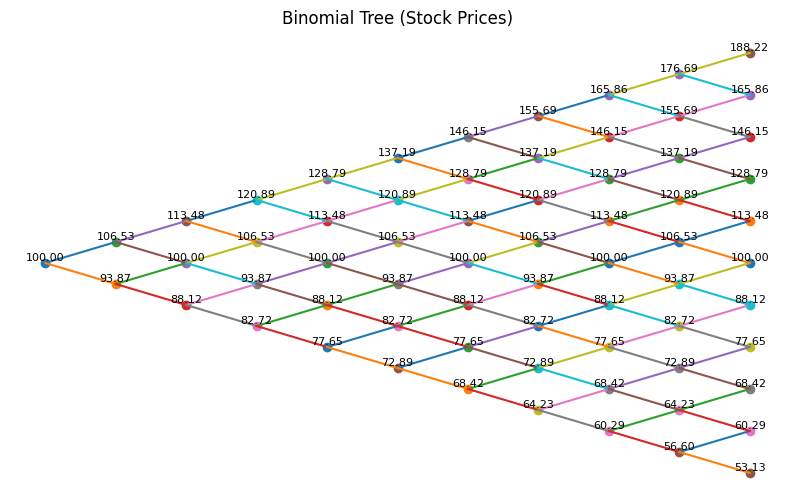

In [132]:

def plot_binomial_tree(S, T, sigma, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    # Build stock price tree
    tree = []
    for i in range(N + 1):
        level = [S * (u**j) * (d**(i - j)) for j in range(i + 1)]
        tree.append(level)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    for i in range(len(tree)):
        for j in range(len(tree[i])):
            x = i
            y = j - i / 2  # center the tree vertically

            # Plot node
            ax.scatter(x, y)
            ax.text(x, y, f"{tree[i][j]:.2f}", fontsize=8,
                    ha='center', va='bottom')

            # Draw branches
            if i < N:
                # Up move
                ax.plot([x, x+1], [y, (j+1) - (i+1)/2])
                # Down move
                ax.plot([x, x+1], [y, j - (i+1)/2])

    ax.set_title("Binomial Tree (Stock Prices)")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Nodes")
    ax.axis('off')

    plt.show()


plot_binomial_tree(S=100, T=1, sigma=0.2, N=10)

### 3. Monte Carlo Simulation

The Monte Carlo (MC) method prices derivatives by simulating the stochastic evolution of the underlying asset under a risk-neutral measure and estimating the discounted expected payoff via statistical averaging.

The fundamental pricing equation is:

$$V_0 = e^{-rT} \mathbb{E}^Q [\Phi(S_t)]$$

where:

- $V_0$: option price
- $r$: risk-free rate
- $q$: continuous dividend yield
- $T$: maturity
- $Q$: risk-neutral probability measure
- $\Phi(S_T)$: payoff function

Monte Carlo approximates this expectation numerically.

Under the Geometric Brownian Motion, the asset evolves as:

$$dS_t = (r - q)S_t dt+\sigma S_t dW_t$$

whose exact solution is:

$$S_T=S_0 exp[(r - q - \frac{1}{2}\sigma ^2)T+\sigma \sqrt{T}Z]$$

where:

- $\sigma$: volatility
- $Z\sim N(0,1)$: standard normal random variable

Simulate M independent paths:

$$S_T^{(i)} ,i=1,…,M$$

Compute payoffs:

$$\Phi^{(i)} = \Phi(S_T^{(i)})$$

Then estimate:

$$\hat{V}_0 = e^{−rT} \frac{1}{M} \sum_{i=1}^{M}\Phi^{(i)}$$

This is an unbiased estimator of the true option price.

To improve efficiency, production systems use:

- Antithetic variates
- Control variates
- Importance sampling
- Quasi-Monte Carlo (low-discrepancy sequences)

These reduce variance without increasing $M$.

In [133]:
def monte_carlo_option(S, K, T, r, sigma, simulations=50000, option_type="call", q=0.0):
    Z = np.random.standard_normal(simulations)
    ST = S * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

    if option_type == "call":
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)

    price = np.exp(-r*T) * np.mean(payoff)
    return price

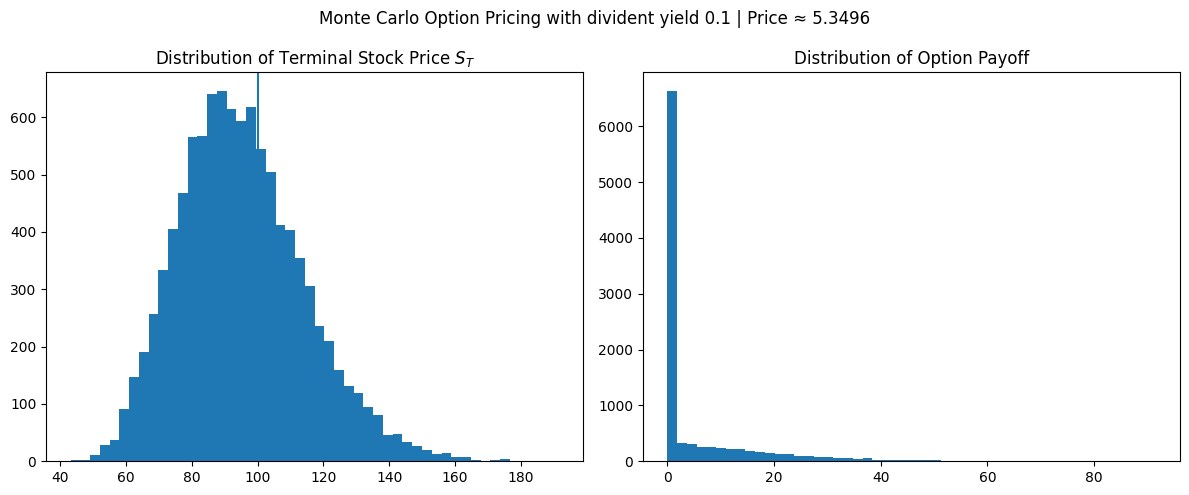

nan

In [134]:
def monte_carlo_visual(S, K, T, r, sigma, simulations=10000, option_type="call", q=0.0):
    Z = np.random.standard_normal(simulations)
    ST = S * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

    if option_type == "call":
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)

    price = np.exp(-r*T) * np.mean(payoff)

    # --- PLOTS ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Distribution of ST
    ax[0].hist(ST, bins=50)
    ax[0].axvline(K)
    ax[0].set_title("Distribution of Terminal Stock Price $S_T$")

    # 2. Distribution of Payoffs
    ax[1].hist(payoff, bins=50)
    ax[1].set_title("Distribution of Option Payoff")

    plt.suptitle(f"Monte Carlo Option Pricing with divident yield {q:.1f} | Price ≈ {price:.4f}")
    plt.tight_layout()
    plt.show()

    return np.nan


# Example
monte_carlo_visual(100, 100, 1, 0.05, 0.2, 10000, "call", 0.1)

### 4. Implied Volatility

Implied Volatility (IV) represents the market's forecast of a likely movement in a security's price over a specific period. When you buy or sell an option, you are trading in an open marketplace. The price of that option fluctuates based on supply and demand. If market participants expect a major event to happen soon—such as an earnings report, a regulatory decision, or a macroeconomic announcement—demand for options increases because investors want to hedge their portfolios or speculate on the price swing. Therefore, IV is often described as the market's gauge of uncertainty or risk. High IV means the market expects a large price swing in either direction, while low IV implies the market expects the asset's price to remain relatively stable. 

Implied volatility is not directly observable in the market. It is extracted backward from an option pricing model, most commonly the Black-Scholes-Merton (BSM) model. Calulation of IV:

$$\text{Find } \sigma \text{ such that: } \text{BlackScholes}(S_0, K, T, r, \sigma, q) - C_{market} = 0$$

In [135]:
def calculate_iv(market_price, S, K, T, r, option_type='call', q=0.0):
    obj_fun = lambda sigma: black_scholes(S, K, T, r, sigma, option_type, q) - market_price
    try:
        return brentq(obj_fun, 0.01, 4.0)
    except:
        return np.nan

In [136]:
ticker = yf.Ticker("SPY")
expirations = ticker.options[:5]
S = ticker.history(period="1d")['Close'].iloc[-1]
r = 0.04
data_list = []

for exp in expirations:
    opt = ticker.option_chain(exp).calls
    opt['T'] = (pd.to_datetime(exp) - pd.Timestamp.now()).days / 365.0
    for idx, row in opt.iterrows():
        iv = calculate_iv(row['lastPrice'], S, row['strike'], row['T'], r)
        data_list.append([row['strike'], row['T'], iv])

df_iv = pd.DataFrame(data_list, columns=['Strike', 'Expiry', 'IV']).dropna()
fig = go.Figure(data=[go.Mesh3d(x=df_iv.Strike, y=df_iv.Expiry, z=df_iv.IV, intensity=df_iv.IV, colorscale='Viridis')])
fig.update_layout(title='Market Implied Volatility Surface for SPY', scene=dict(xaxis_title='Strike', yaxis_title='Time to Expiry', zaxis_title='IV'))
fig.show()

C:\Users\i001610\AppData\Local\Temp\ipykernel_14004\2427289639.py:4: RuntimeWarning: invalid value encountered in sqrt
  d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
C:\Users\i001610\AppData\Local\Temp\ipykernel_14004\2427289639.py:5: RuntimeWarning: invalid value encountered in sqrt
  d2 = d1 - sigma*np.sqrt(T)
C:\Users\i001610\AppData\Local\Temp\ipykernel_14004\2427289639.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))


### 5. Heston Model

The Heston model describes the joint dynamics of an asset price $S_t$ and its instantaneous variance $v_t$ under a risk-neutral measure using two coupled Stochastic Differential Equations (SDEs):  

$$dS_t = (r - q) S_t dt + \sqrt{v_t} S_t dW_t^S$$

$$dv_t = \kappa(\theta - v_t)dt + \xi \sqrt{v_t} dW_t^v$$

The random shocks to the asset ($dW_t^S$) and its variance ($dW_t^v$) are correlated Wiener processes:

$$dW_t^S \cdot dW_t^v = \rho dt$$

Where

- $S_t$: The asset price at time $t$.
- $r$: The risk-free interest rate.
- $q$: Continuous divident yield.
- $v_t$: The instantaneous variance (therefore, $\sqrt{v_t}$ is the volatility).
- $\kappa$ (Mean Reversion Speed): Determines how quickly the variance reverts toward its long-term average.
- $\theta$ (Long-Term Variance): The structural mean/level that variance pulls back to over time.
- $\xi$ (Volatility of Volatility): Dictates the variance of the variance process. It governs the kurtosis (fat tails) of the asset returns distribution.
- $\rho$ (Correlation Parameter): The correlation between asset returns and volatility shocks. This captures the "leverage effect", when stock prices drop, market anxiety and volatility spike. This parameter directly governs the asymmetry or skew of the volatility surface.

Heston model yields a semi-analytical closed-form solution for European options. Heston used the fact that the risk-neutral probability of an option expiring in-the-money can be evaluated if we know the characteristic function of the log-asset price. Since the Heston solution was unstable

The European Call option price is given by:

$$C(S_t, v_t, K, T) = S_t e^{-q(T-t)} P_1 - K e^{-r(T-t)} P_2$$

And for the Put-Call Parity:

$$P(S_t, v_t, K, T) = C(S_t, v_t, K, T) - S_t e^{-q\tau} + K e^{-r\tau}$$

Where $P_1$ and $P_2$ represent risk-neutral probabilities, calculated by taking the inverse Fourier Transform of the Characteristic Function $\phi$:
$$P_j(x, v, \tau; \ln K) = \frac{1}{2} + \frac{1}{\pi} \int_{0}^{\infty} \text{Re}[ \frac{e^{-i u \ln K} \phi_j(u; x, v, \tau)}{i u}] du$$

Where 
- $x = \ln(S_t)$
- $\tau = T - t$

and the Characteristic Function ($\phi_j$) is

$$\phi_j(u; x, v, \tau) = \exp \left\{ C_j(\tau, u) + D_j(\tau, u) v + i u x \right\}$$

Heston defined the coefficient integrations as:
$$C_j(\tau, u) = i u (r-q) \tau + \frac{\kappa \theta}{\xi^2} \left[ (b_j - \rho \xi i u - d_j)\tau - 2 \ln \left( \frac{1 - g_j e^{-d_j \tau}}{1 - g_j} \right) \right]$$
$$D_j(\tau, u) = \frac{b_j - \rho \xi i u - d_j}{\xi^2} \left( \frac{1 - e^{-d_j \tau}}{1 - g_j e^{-d_j \tau}} \right)$$

Where:
- $d_j = \sqrt{(\rho \xi i u - b_j)^2 - \xi^2 (2 u_j i u - u^2)}$
- $g_j = \frac{b_j - \rho \xi i u - d_j}{b_j - \rho \xi i u + d_j}$

For $j=1$: $u_1 = \frac{1}{2}, \ b_1 = \kappa - \rho\xi$

For $j=2$: $u_2 = -\frac{1}{2}, \ b_2 = \kappa$


In [137]:
# ==========================================================
# Characteristic Heston function (Estable y Libre de Warnings)
# ==========================================================
def heston_cf(u, jj, S, T, r, kappa, theta, sigma, rho, v0, q=0.0):
    i = 1j
    u = complex(u)
    S = float(S)
    T = float(T)
    r = float(r)
    q = float(q)
    kappa = float(kappa)
    theta = float(theta)
    sigma = float(max(sigma, 1e-5))
    rho = float(rho)
    v0 = float(v0)
    
    x = math.log(S)

    if jj == 1: 
        uj = 0.5
        b = kappa - rho * sigma
    else: 
        uj = -0.5
        b = kappa

    d = cmath.sqrt((rho * sigma * i * u - b)**2 - sigma**2 * (2 * uj * i * u - u**2))
    
    denom_g = b - rho * sigma * i * u + d
    if abs(denom_g) < 1e-6: denom_g = 1e-6 + 0j
    g = (b - rho * sigma * i * u - d) / denom_g
    
    exp_minus_dt = cmath.exp(-d * T)

    denom_exp = 1.0 - g * exp_minus_dt
    if abs(denom_exp) < 1e-6: denom_exp = 1e-6 + 0j
        
    denom_minus_g = 1.0 - g
    if abs(denom_minus_g) < 1e-6: denom_minus_g = 1e-6 + 0j
    
    D = ((b - rho * sigma * i * u - d) / (sigma**2)) * ((1.0 - exp_minus_dt) / denom_exp)
    C = i * u * (r - q) * T + (kappa * theta / (sigma**2)) * ((b - rho * sigma * i * u - d) * T - 2.0 * cmath.log(denom_exp / denom_minus_g))

    return cmath.exp(C + D * v0 + i * u * x)


# ==========================================================
# Probabilities P1 and P2 (Seguras contra singularidades)
# ==========================================================
gl_nodes, gl_weights = np.polynomial.legendre.leggauss(192)
def heston_probability(j, S, K, T, r, kappa, theta, sigma, rho, v0, q=0.0):
    i = 1j
    log_K = math.log(float(K))
    
    # Intervalo de integración [a, b]
    a = 1e-10
    b = 500.0
    
    # Mapeo de los nodos de Gauss-Legendre [-1, 1] al intervalo [a, b]
    u_points = 0.5 * (b - a) * gl_nodes + 0.5 * (b + a)
    weights = 0.5 * (b - a) * gl_weights
    
    integral_sum = 0.0
    
    for u, w in zip(u_points, weights):
        try:
            cf = heston_cf(u, j, S, T, r, kappa, theta, sigma, rho, v0, q=q)
            val_complex = cmath.exp(-i * u * log_K) * cf / (i * u)
            integral_sum += w * float(val_complex.real)
        except (ValueError, ZeroDivisionError, OverflowError):
            continue
            
    return 0.5 + integral_sum / np.pi


# ==========================================================
# Option Price with Heston
# ==========================================================
def heston_price(S, K, T, r, kappa, theta, sigma, rho, v0, option_type="call", q=0.0):
    P1 = heston_probability(1, S, K, T, r, kappa, theta, sigma, rho, v0, q=q)
    P2 = heston_probability(2, S, K, T, r, kappa, theta, sigma, rho, v0, q=q)

    call = S * np.exp(-q * T) * P1 - K * np.exp(-r * T) * P2

    if option_type.lower() == "call": return call
    else: return max(0.0, call - S * np.exp(-q * T) + K * np.exp(-r * T))


In [138]:
def objective_function(params, market_prices, strikes, maturities, S0, r, option_type="call", q=0.0):
    kappa, theta, sigma_v, rho, v0 = params
    if kappa <= 0 or theta <= 0 or sigma_v <= 0 or rho <= -1.0 or rho >= 1.0: return 1e12
    
    model_prices = []

    feller_penalty = 0.0
    if 2 * kappa * theta < sigma_v**2: feller_penalty = 100.0 * ((sigma_v**2) - (2 * kappa * theta))

    for i in range(len(strikes)):
        k = strikes[i]
        t = maturities[i]
        price = heston_price(S0, k, t, r, kappa, theta, sigma_v, rho, v0, option_type=option_type, q=q)
        model_prices.append(price)

    market_prices = np.array(market_prices)
    model_prices = np.array(model_prices)
    
    return np.sqrt(np.mean(((market_prices - model_prices) / market_prices) ** 2 + feller_penalty))

### 6. Merton Jump-Diffusion (MJD) Model

Standard models assume prices move smoothly. In reality, assets can experience sudden, gaping moves. Merton's model superimposes randomly occurring jumps on top of the traditional Geometric Brownian Motion. The model's Stochastic Differential Equation is defined as:

$\frac{dS_{t}}{S_{t}}=(r - q - \lambda k)dt + \sigma_{dif} dW_{t}+d(\sum _{i=1}^{N_{t}}(J_{i}-1))$

Where:
- $r$ is the risk-free rate
- $\sigma_{dif}$ is the continuous volatility or difusion volatility
- $W_{t}$ is a standard Wiener process
- $N_{t}$ is a Poisson process with intensity $\lambda$, representing the number of jumps that have occurred up to time $t$
- $J_{i}$ represents the random jump size
- $k = E[J_i - 1]$ is the expected relative jump size to ensure the model remains risk-neutral

The difusion volatility is calculated as follows: $\sigma_{\text{difusión}} = \sqrt{\sigma_{\text{Mercado}}^2 - \lambda \cdot (\mu_j^2 + \sigma_j^2)}$, where $\ln(J_j) \sim N(\mu_j, \sigma_j^2)$. This implies that  $\mu_j$ is the average magnitud of the jumps and  $\sigma_j$ is the uncertainty or volatility of the jumps.

Why It Matters:

- Kurtosis and Skewness: Pure diffusion struggles to account for the actual market phenomena of extreme crash events and heavy tails. MJD accurately accommodates this.
- Option Pricing: Because jump risk is largely unhedgeable, it alters the prices of out-of-the-money options. The MJD pricing formula essentially acts as a weighted sum of Black-Scholes formulas for varying jump amounts.
- Gap Risk: Useful to calculate and prepare for severe gaps in prices.

In [139]:
def merton_option_pricing(S0, K, T, r, sigma, q, lam, mu_j, sigma_j, option_type="call", N_simulations=100000):
    k = np.exp(mu_j + 0.5 * sigma_j**2) - 1

    Z = np.random.standard_normal(N_simulations)
    N_jumps = np.random.poisson(lam * T, N_simulations)
    
    jump_factor = np.ones(N_simulations)
    for i in range(N_simulations):
        if N_jumps[i] > 0:
            log_jumps = np.random.normal(mu_j, sigma_j, N_jumps[i])
            jump_factor[i] = np.exp(np.sum(log_jumps))
    
    drift = (r - q - 0.5 * sigma**2 - lam * k) * T
    diffusion = sigma * np.sqrt(T) * Z
    ST = S0 * np.exp(drift + diffusion) * jump_factor
    
    if option_type.lower() == "call":
        payoffs = np.maximum(ST - K, 0)
    else:
        payoffs = np.maximum(K - ST, 0)
    
    option_price = np.exp(-r * T) * np.mean(payoffs)
    
    return option_price


### 7. Greeks

The Greeks are a set of mathematical measures that quantify the different dimensions of risk in an option position.

#### **Delta ($\Delta$)**

The Delta of an option, $\Delta$, is the ratio of the change in price of an option to the change in price of the underlying asset. The general formula for Delta is as follows:

$$\Delta = \frac{\partial V}{\partial S}$$

And for the case of the Black-Scholes model:

- Call : $e^{-q(T-t)}N(d_1)$
- Put : $-e^{-q(T-t)}N(-d_1)$

#### **Gamma ($\Gamma$)**

The Gamma of an option, $\Gamma$, represents the expected change in the delta of an option. It measures the curvature of the option price function not captured by delta. The general formula for Gamma is as follows:

$$\Gamma = \frac{\partial^2 V}{\partial S^2}$$

And for the case of the Black-Scholes model: $\frac{e^{-q(T-t)}N'(d_1)}{S\sigma \sqrt{T-t}}$

#### **Theta ($\Theta$)**

The Theta of an option, $\Theta$, measures the option’s sensitivity to a decrease in time to expiration. Theta is also termed the time decay of an option. The general formula for Theta is as follows:

$$\Theta = \frac{\partial V}{\partial t}$$

And for the case of the Black-Scholes model:

- Call : $-\frac{Se^{-q(T-t)}N'(d_1)\sigma}{2\sigma \sqrt{T-t}} + qSe^{-q(T-t)}N(d_1) - rKe^{-r(T-t)}N(d_2)$
- Put : $-\frac{Se^{-q(T-t)}N'(d_1)\sigma}{2\sigma \sqrt{T-t}} - qSe^{-q(T-t)}N(d_1) + rKe^{-r(T-t)}N(-d_2)$

#### **Vega**

The Vega of an option measures the sensitivity of the option’s price to changes in the volatility of the underlying stock. The general formula for Vega is as follows:

$$Vega = \frac{\partial V}{\partial \sigma}$$

And for the case of the Black-Scholes model: $Se^{-q(T-t)}N'(d_1)\sqrt{T-t}$

#### **Rho ($\rho$)**

The Rho of an option, $\rho$, measures an option’s sensitivity to changes in the risk-free rate. The general formula for Rho is as follows:

$$\rho = \frac{\partial V}{\partial r}$$

And for the case of the Black-Scholes model:

- Call : $K(T-t)e^{-r(T-t)}N(d_2)$
- Put : $-K(T-t)e^{-r(T-t)}N(-d_2)$

In [140]:
def optionDelta (S, K, T, r, sigma, option_type="call", q=0.0):
    d1 = (np.log(S/K) + (r - q + sigma**2/2)* T)/(sigma*np.sqrt(T))
    if option_type == "call":
        delta = np.exp(-q * T) * norm.cdf(d1, 0, 1)
    else:
        delta = -np.exp(-q * T) * norm.cdf(-d1, 0, 1)
    return delta

def optionGamma (S, K, T, r, sigma, q=0.0):
    d1 = (np.log(S/K) + (r - q + sigma**2/2)* T)/(sigma*np.sqrt(T))
    gamma = (np.exp(-q * T) * norm.pdf(d1, 0, 1))/ (S * sigma * np.sqrt(T))
    return gamma

def optionTheta (S, K, T, r, sigma, option_type="call", q=0.0):
    "Calculates option theta"
    d1 = (np.log(S/K) + (r - q + sigma**2/2)* T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        theta = - ((S * np.exp(-q * T) * norm.pdf(d1, 0, 1) * sigma) / (2 * np.sqrt(T))) + q * S * np.exp(-q * T) * norm.cdf(d1, 0, 1) - r * K * np.exp(-r*T) * norm.cdf(d2, 0, 1)
    else:
        theta = - ((S * np.exp(-q * T) * norm.pdf(d1, 0, 1) * sigma) / (2 * np.sqrt(T))) + q * S * np.exp(-q * T) * norm.cdf(d1, 0, 1) + r * K * np.exp(-r*T) * norm.cdf(-d2, 0, 1)
    return theta/365

def optionVega(S, K, T, r, sigma, q=0.0):
    d1 = (np.log(S/K) + (r - q + sigma**2/2)*T) / (sigma*np.sqrt(T))
    return S * np.exp(-q * T) * np.sqrt(T) * norm.pdf(d1)

def optionRho(S, K, T, r, sigma, option_type="call", q=0.0):
    "Calculates option rho"
    d1 = (np.log(S/K) + (r - q + sigma**2/2)* T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        rho = 0.01 * K * T * np.exp(-r*T) * norm.cdf(d2, 0, 1)
    else:
        rho = 0.01 * -K * T * np.exp(-r*T) * norm.cdf(-d2, 0, 1)
    return rho

### 8. Principal Script

This analysis presents a comparative breakdown of European option prices and respective risk sensitivities (Greeks) for an at-the-money (ATM) option with a T-year maturity. The matrix evaluates pricing across five distinct quantitative frameworks, contrasting a non-dividend baseline against a continuous dividend yield.

In [141]:
# Define parameters
S = 100 # initial stock price
K = 100 # strike price
T = 1 # time to maturity
r = 0.05 # risk-free rate
sigma = 0.2 # implied volatility
q = 0.02 # continuous divident yield

kappa = 2.0 # Rate of mean reversion; the speed at which volatility reverts to its long-term average
theta = 0.05 # Long-term average variance (i.e., the long-term mean of the volatility squared)
ssigma = 0.4 # Volatility of volatility ("vol of vol"); describes how much the variance fluctuates.
rho = -0.7 # Correlation between the stock price and the variance (usually negative for equities to reflect leverage)
v0 = 0.04 # Current/Initial instantaneous variance of the underlying asset

lam = 1.0 # 1 average jump per year
mu_j = -0.15 # Jumps average a 15% drop
sigma_j = 0.10 # Jump uncertainty (10%)
sigma_difusion = sigma*0.6

print(f"Parameters: \n - Initial stock price: {S} \n - Strike price: {K} \n - Time to Maturity: {T} \n - Risk-free Rate: {r} \n - Implied Volatility: {sigma} \n - Continuous divident yield: {q}")
print(f" - Rate of mean reversion: {kappa} \n - Long-term average variance: {theta} \n - Volatility of volatility {ssigma} \n - Correlation between the stock price and the variance: {rho} \n - Instantaneous variance of the underlying asset: {v0}")
print(f" - Average Jump per year: {lam} \n - Jumps average drop: {mu_j} \n - Jump uncertainty: {sigma_j} \n - Difusion volatility: {sigma_difusion} \n")

df_greeks = pd.DataFrame({
    " ": ["Black-Scholes Model Pricing", "Binomial Model Pricing", "Monte Carlo Pricing", "Heston Model Pricing", "Merton Model Pricing",
          "Greek: Delta", "Greek: Gamma", "Greek: Theta", "Greek: Vega", "Greek: Rho"],
    "Call Option": [
        black_scholes(S,K,T,r,sigma, "call"),
        binomial_option(S,K,T,r,sigma,2000, "call"),
        monte_carlo_option(S,K,T,r,sigma,option_type="call"),
        heston_price(S, K, T, r, kappa, theta, ssigma, rho, v0, "call"),
        merton_option_pricing(S, K, T, r, sigma_difusion, 0, lam, mu_j, sigma_j, "call"),
        optionDelta(S, K, T, r, sigma, "call"),
        optionGamma(S, K, T, r, sigma),
        optionTheta(S, K, T, r, sigma, "call"),
        optionVega(S, K, T, r, sigma),
        optionRho(S, K, T, r, sigma, "call")
    ],
    "Call Option With Dividend": [
        black_scholes(S,K,T,r,sigma, "call", q),
        binomial_option(S,K,T,r,sigma,2000, "call",q),
        monte_carlo_option(S,K,T,r,sigma,option_type="call",q=q),
        heston_price(S, K, T, r, kappa, theta, ssigma, rho, v0, "call", q),
        merton_option_pricing(S, K, T, r, sigma_difusion, q, lam, mu_j, sigma_j, "call"),
        optionDelta(S, K, T, r, sigma, "call", q),
        optionGamma(S, K, T, r, sigma, q),
        optionTheta(S, K, T, r, sigma, "call", q),
        optionVega(S, K, T, r, sigma, q),
        optionRho(S, K, T, r, sigma, "call", q)
    ],
    "Put Option": [
        black_scholes(S,K,T,r,sigma, "put"),
        binomial_option(S,K,T,r,sigma,2000, "put"),
        monte_carlo_option(S,K,T,r,sigma,option_type="put"),
        heston_price(S, K, T, r, kappa, theta, ssigma, rho, v0, "put"),
        merton_option_pricing(S, K, T, r, sigma_difusion, 0, lam, mu_j, sigma_j, "put"),
        optionDelta(S, K, T, r, sigma, "put"),
        optionGamma(S, K, T, r, sigma),
        optionTheta(S, K, T, r, sigma, "put"),
        optionVega(S, K, T, r, sigma),
        optionRho(S, K, T, r, sigma, "put")
    ],
    "Put Option With Dividend": [
        black_scholes(S,K,T,r,sigma, "put", q),
        binomial_option(S,K,T,r,sigma,2000, "put",q),
        monte_carlo_option(S,K,T,r,sigma,option_type="put",q=q),
        heston_price(S, K, T, r, kappa, theta, ssigma, rho, v0, "put", q),
        merton_option_pricing(S, K, T, r, sigma_difusion, q, lam, mu_j, sigma_j, "put"),
        optionDelta(S, K, T, r, sigma, "put", q),
        optionGamma(S, K, T, r, sigma, q),
        optionTheta(S, K, T, r, sigma, "put", q),
        optionVega(S, K, T, r, sigma, q),
        optionRho(S, K, T, r, sigma, "put", q)
    ]
})
pd.options.display.float_format = '{:.4f}'.format
print("Option Prices Comparison Table:")
print(df_greeks.to_string(index=False))

Parameters: 
 - Initial stock price: 100 
 - Strike price: 100 
 - Time to Maturity: 1 
 - Risk-free Rate: 0.05 
 - Implied Volatility: 0.2 
 - Continuous divident yield: 0.02
 - Rate of mean reversion: 2.0 
 - Long-term average variance: 0.05 
 - Volatility of volatility 0.4 
 - Correlation between the stock price and the variance: -0.7 
 - Instantaneous variance of the underlying asset: 0.04
 - Average Jump per year: 1.0 
 - Jumps average drop: -0.15 
 - Jump uncertainty: 0.1 
 - Difusion volatility: 0.12 

Option Prices Comparison Table:
                             Call Option  Call Option With Dividend  Put Option  Put Option With Dividend
Black-Scholes Model Pricing      10.4506                     9.2270      5.5735                    6.3301
     Binomial Model Pricing      10.4496                     9.2260      5.5725                    6.3291
        Monte Carlo Pricing      10.4934                     9.2367      5.5604                    6.2745
       Heston Model Pricing  

**Visual Representation of the Call and Put Option Prices and Greeks using the Black-Sholes model**

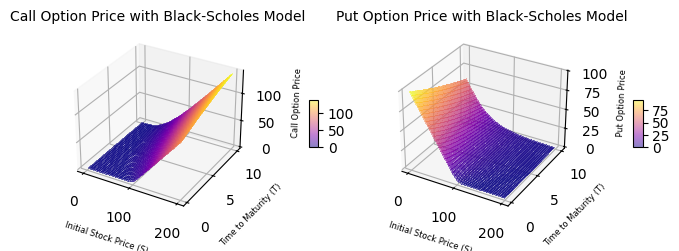

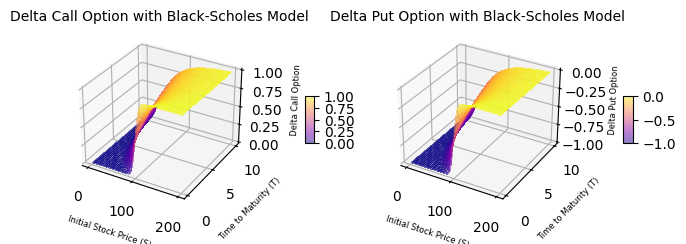

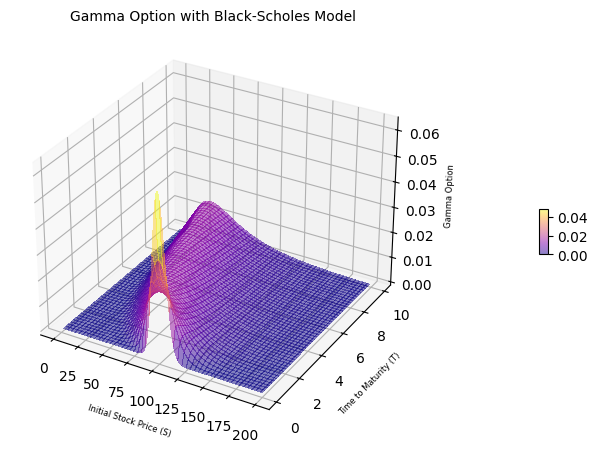

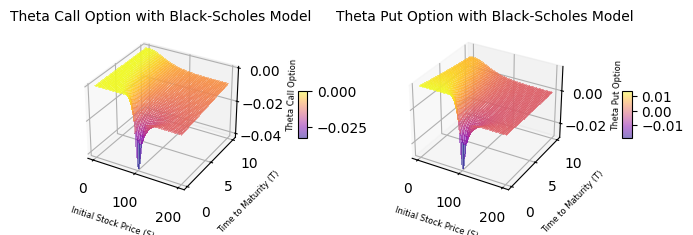

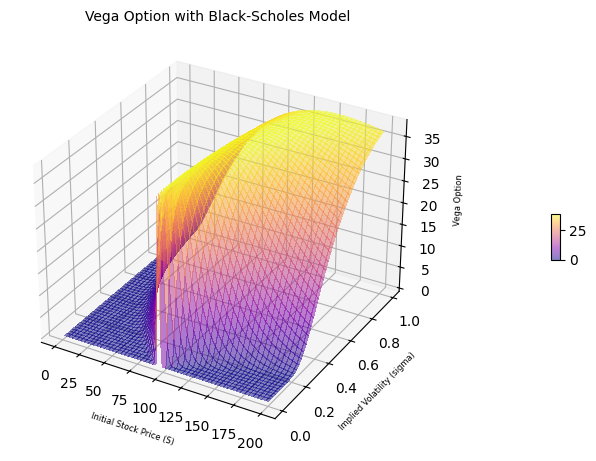

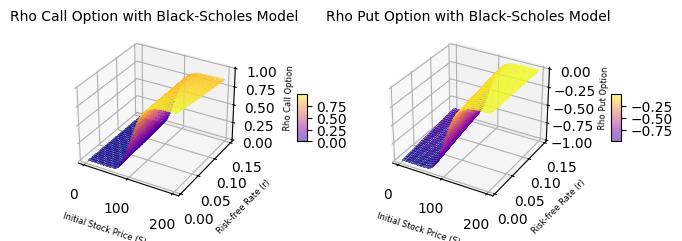

In [142]:
# =================================
# === Call and Put Option Price ===
# =================================

fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={"projection": "3d"}, constrained_layout=True)

# Make data.
S = np.arange(1, 200, 1)
T = np.arange(0.1, 10, 0.1)
S, T = np.meshgrid(S, T)

BS = black_scholes(S,K,T,r,sigma, "call")
fig.colorbar(ax1.plot_surface(S, T, BS, cmap='plasma', linewidth=0, antialiased=False, alpha=0.5), shrink=0.1, aspect=5, pad=0.3)
ax1.set_xlabel('Initial Stock Price (S)', fontsize=6)
ax1.set_ylabel('Time to Maturity (T)', fontsize=6)
ax1.set_zlabel('Call Option Price', fontsize=6)
ax1.set_title("Call Option Price with Black-Scholes Model", fontsize=10)

BS = black_scholes(S,K,T,r,sigma, "put")
fig.colorbar(ax2.plot_surface(S, T, BS, cmap='plasma', linewidth=0, antialiased=False, alpha=0.5), shrink=0.1, aspect=5, pad=0.3)
ax2.set_xlabel('Initial Stock Price (S)', fontsize=6)
ax2.set_ylabel('Time to Maturity (T)', fontsize=6)
ax2.set_zlabel('Put Option Price', fontsize=6)
ax2.set_title("Put Option Price with Black-Scholes Model", fontsize=10)
plt.show()


# ==========================
# === Delta Call and Put ===
# ==========================

fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={"projection": "3d"}, constrained_layout=True)

# Make data.
S = np.arange(1, 200, 1)
T = np.arange(0.1, 10, 0.1)
S, T = np.meshgrid(S, T)

Delta = optionDelta(S,K,T,r,sigma, "call")
fig.colorbar(ax1.plot_surface(S, T, Delta, cmap='plasma', linewidth=0, antialiased=False, alpha=0.5), shrink=0.1, aspect=5, pad=0.3)
ax1.set_xlabel('Initial Stock Price (S)', fontsize=6)
ax1.set_ylabel('Time to Maturity (T)', fontsize=6)
ax1.set_zlabel('Delta Call Option', fontsize=6)
ax1.set_title("Delta Call Option with Black-Scholes Model", fontsize=10)

Delta = optionDelta(S,K,T,r,sigma, "put")
fig.colorbar(ax2.plot_surface(S, T, Delta, cmap='plasma', linewidth=0, antialiased=False, alpha=0.5), shrink=0.1, aspect=5, pad=0.3)
ax2.set_xlabel('Initial Stock Price (S)', fontsize=6)
ax2.set_ylabel('Time to Maturity (T)', fontsize=6)
ax2.set_zlabel('Delta Put Option', fontsize=6)
ax2.set_title("Delta Put Option with Black-Scholes Model", fontsize=10)
plt.show()


# =============
# === Gamma ===
# =============

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

# Make data.
S = np.arange(1, 200, 1)
T = np.arange(0.1, 10, 0.1)
S, T = np.meshgrid(S, T)

Gamma = optionGamma(S,K,T,r,sigma)
fig.colorbar(ax.plot_surface(S, T, Gamma, cmap='plasma', linewidth=0, antialiased=False, alpha=0.5), shrink=0.1, aspect=5, pad=0.3)
ax.set_xlabel('Initial Stock Price (S)', fontsize=6)
ax.set_ylabel('Time to Maturity (T)', fontsize=6)
ax.set_zlabel('Gamma Option', fontsize=6)
ax.set_title("Gamma Option with Black-Scholes Model", fontsize=10)
plt.show()


# ==========================
# === Theta Call and Put ===
# ==========================

fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={"projection": "3d"}, constrained_layout=True)

# Make data.
S = np.arange(1, 200, 1)
T = np.arange(0.1, 10, 0.1)
S, T = np.meshgrid(S, T)

Theta = optionTheta(S,K,T,r,sigma, "call")
fig.colorbar(ax1.plot_surface(S, T, Theta, cmap='plasma', linewidth=0, antialiased=False, alpha=0.5), shrink=0.1, aspect=5, pad=0.3)
ax1.set_xlabel('Initial Stock Price (S)', fontsize=6)
ax1.set_ylabel('Time to Maturity (T)', fontsize=6)
ax1.set_zlabel('Theta Call Option', fontsize=6)
ax1.set_title("Theta Call Option with Black-Scholes Model", fontsize=10)

Theta = optionTheta(S,K,T,r,sigma, "put")
fig.colorbar(ax2.plot_surface(S, T, Theta, cmap='plasma', linewidth=0, antialiased=False, alpha=0.5), shrink=0.1, aspect=5, pad=0.3)
ax2.set_xlabel('Initial Stock Price (S)', fontsize=6)
ax2.set_ylabel('Time to Maturity (T)', fontsize=6)
ax2.set_zlabel('Theta Put Option', fontsize=6)
ax2.set_title("Theta Put Option with Black-Scholes Model", fontsize=10)
plt.show()


# =============
# === Vega ===
# =============

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

# Make data
T = 1 # time to maturity
r = 0.05 # risk-free rate
S = np.arange(1, 200, 1)
sigma = np.arange(0.01, 1, 0.01)
S, sigma = np.meshgrid(S, sigma)

Vega = optionVega(S,K,T,r,sigma)
fig.colorbar(ax.plot_surface(S, sigma, Vega, cmap='plasma', linewidth=0, antialiased=False, alpha=0.5), shrink=0.1, aspect=5, pad=0.3)
ax.set_xlabel('Initial Stock Price (S)', fontsize=6)
ax.set_ylabel('Implied Volatility (sigma)', fontsize=6)
ax.set_zlabel('Vega Option', fontsize=6)
ax.set_title("Vega Option with Black-Scholes Model", fontsize=10)
plt.show()


# ==========================
# === Rho Call and Put ===
# ==========================

fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={"projection": "3d"}, constrained_layout=True)

# Make data
T = 1 # time to maturity
sigma = 0.2 # implied volatility
S = np.arange(1, 200, 1)
r = np.arange(0.005, 0.15, 0.005)
S, r = np.meshgrid(S, r)

Rho = optionRho(S,K,T,r,sigma, "call")
fig.colorbar(ax1.plot_surface(S, r, Rho, cmap='plasma', linewidth=0, antialiased=False, alpha=0.5), shrink=0.1, aspect=5, pad=0.3)
ax1.set_xlabel('Initial Stock Price (S)', fontsize=6)
ax1.set_ylabel('Risk-free Rate (r)', fontsize=6)
ax1.set_zlabel('Rho Call Option', fontsize=6)
ax1.set_title("Rho Call Option with Black-Scholes Model", fontsize=10)

Rho = optionRho(S,K,T,r,sigma, "put")
fig.colorbar(ax2.plot_surface(S, r, Rho, cmap='plasma', linewidth=0, antialiased=False, alpha=0.5), shrink=0.1, aspect=5, pad=0.3)
ax2.set_xlabel('Initial Stock Price (S)', fontsize=6)
ax2.set_ylabel('Risk-free Rate (r)', fontsize=6)
ax2.set_zlabel('Rho Put Option', fontsize=6)
ax2.set_title("Rho Put Option with Black-Scholes Model", fontsize=10)
plt.show()

Real Example for a Stock

In [143]:
fred = Fred(api_key='78998e3738b162f8081368c92fb5ca21')

ticker = "AAPL"
stock = yf.Ticker(ticker)

# Actual Price
hist = stock.history(period="3y")
S = hist["Close"].iloc[-1]

K = S # strike price
T = 1

# Select an expiration date (target roughly 30 to 45 days out for liquidity)
target_days = 365 * T
today = datetime.today().date()
selected_exp1 = min(stock.options, key=lambda x: abs((datetime.strptime(x, "%Y-%m-%d").date() - today).days - target_days))
T1 = (datetime.strptime(selected_exp1, "%Y-%m-%d").date() - today).days / 365.0

options_above = [x for x in stock.options if (datetime.strptime(x, "%Y-%m-%d").date() - today).days >= target_days]
if not options_above: selected_exp2 = max(stock.options)
else: selected_exp2 = min(options_above, key=lambda x: (datetime.strptime(x, "%Y-%m-%d").date() - today).days)
T2 = (datetime.strptime(selected_exp2, "%Y-%m-%d").date() - today).days / 365.0


calls1 = stock.option_chain(selected_exp1).calls[['lastPrice', 'strike']]
calls1["maturity"] = T1
calls2 = stock.option_chain(selected_exp2).calls[['lastPrice', 'strike']]
calls2["maturity"] = T2

calls = pd.concat([calls1, calls2])

# Continuous Anualized Dividend (q)
try:
    q = (stock.info.get('lastDividendValue', 0.25) * 4) / S
except Exception:
    q = 0.0

# Risk Free Rate (r) from FRED
try:
    r = fred.get_series('DTB3').iloc[-1] / 100
except Exception:
    r = 0.045

# Implied Volatility (sigma)
try:
    sigma_t1 = calculate_iv(calls1.iloc[(calls1['strike'] - S).abs().idxmin()]['lastPrice'], S, K, T, r, option_type='call', q=q)
    sigma_t2 = calculate_iv(calls2.iloc[(calls2['strike'] - S).abs().idxmin()]['lastPrice'], S, K, T, r, option_type='call', q=q)
    sigma = (sigma_t1 + sigma_t2) / 2.0

except Exception:
    sigma = (np.log(hist['Close'] / hist['Close'].shift(1))).std() * np.sqrt(252)
if np.isnan(sigma): sigma = (np.log(hist['Close'] / hist['Close'].shift(1))).std() * np.sqrt(252)

# --------------------------------
# Calibration of Heston Parameters
# --------------------------------

initial_params = [2.0, 0.2, 0.3, -0.5, 0.04]

bounds = [
        (0.1, 10.0),                                      # kappa: mean reversion speed
        (0.01, 1.0),                                      # theta bound centered on market
        (0.01, 1.0),                                      # sigma_v: vol of vol
        (-0.99, 0.99),                                    # rho: leverage effect (usually negative)
        (0.01, 1)                                         # v0
    ]

# Paso local con restricciones utilizando el algoritmo L-BFGS-B
local_result = minimize(
    objective_function, x0=initial_params, method='L-BFGS-B', bounds=bounds, 
    args=(calls['lastPrice'].to_numpy(), calls['strike'].to_numpy(), calls['maturity'].to_numpy(), S, r, "call", q),
    options={'disp': True})

k_cal, th_cal, sig_cal, rho_cal, v0_cal = local_result.x


# --------------------------------
# Calibration of Merton Parameters
# --------------------------------

hist['Returns'] = hist['Close'].pct_change(fill_method=None)

# Define a jump if the daily movement surpases 3*vol
std_returns = hist['Returns'].std()
mean_returns = hist['Returns'].mean()
jumps = hist[abs(hist['Returns'] - mean_returns) > 3 * std_returns]

lam_estimated = len(jumps) / 3.0 # Average frequency of the jumps
mu_j_estimated = jumps['Returns'].mean() # Magnitude of the jump
sigma_j_estimated = jumps['Returns'].std() # Uncertainty of the jump
sigma_difusion_merton = np.sqrt(max(0.01, sigma**2 - lam_estimated * (mu_j_estimated**2 + sigma_j_estimated**2))) # Continuous difusion volatility

print(f"Initial Parameters from {ticker}:")
print(f" - Initial stock price: {S:.4f} \n - Strike price: {K:.4f} \n - Time to Maturity: {T} \n - Risk-free Rate: {r:.4f} \n - Implied Volatility: {sigma:.4f} \n - Continuous divident yield: {q:.4f}")
print(f" - Rate of mean reversion: {k_cal:.4f} \n - Long-term average variance: {th_cal:.4f} \n - Volatility of volatility {sig_cal:.4f} \n - Correlation between the stock price and the variance: {rho_cal:.4f} \n - Instantaneous variance of the underlying asset: {v0_cal:.4f}")
print(f" - Average Jump per year: {lam_estimated:.4f} \n - Jumps average drop: {mu_j_estimated:.4f} \n - Jump uncertainty: {sigma_j_estimated:.4f} \n - Difusion volatility: {sigma_difusion_merton:.4f} \n")

df_greeks = pd.DataFrame({
    " ": ["Black-Scholes Model Pricing", "Binomial Model Pricing", "Monte Carlo Pricing", "Heston Model Pricing", "Merton Model Pricing",
          "Greek: Delta", "Greek: Gamma", "Greek: Theta", "Greek: Vega", "Greek: Rho"],
    "Call Option": [
        black_scholes(S,K,T,r,sigma, "call", q),
        binomial_option(S,K,T,r,sigma, 200, "call",q),
        monte_carlo_option(S,K,T,r,sigma,option_type="call",q=q),
        heston_price(S, K, T, r, k_cal, th_cal, sig_cal, rho_cal, v0_cal, "call", q),
        merton_option_pricing(S, K, T, r, sigma_difusion_merton, q, lam_estimated, mu_j_estimated, sigma_j_estimated, "call"),
        optionDelta(S, K, T, r, sigma, "call", q),
        optionGamma(S, K, T, r, sigma, q),
        optionTheta(S, K, T, r, sigma, "call", q),
        optionVega(S, K, T, r, sigma, q),
        optionRho(S, K, T, r, sigma, "call", q)
    ],
    "Put Option": [
        black_scholes(S,K,T,r,sigma, "put", q),
        binomial_option(S,K,T,r,sigma,200, "put",q),
        monte_carlo_option(S,K,T,r,sigma,option_type="put",q=q),
        heston_price(S, K, T, r, k_cal, th_cal, sig_cal, rho_cal, v0_cal, "put", q),
        merton_option_pricing(S, K, T, r, sigma_difusion_merton, q, lam_estimated, mu_j_estimated, sigma_j_estimated, "put"),
        optionDelta(S, K, T, r, sigma, "put", q),
        optionGamma(S, K, T, r, sigma, q),
        optionTheta(S, K, T, r, sigma, "put", q),
        optionVega(S, K, T, r, sigma, q),
        optionRho(S, K, T, r, sigma, "put", q)
    ]
})
pd.options.display.float_format = '{:.4f}'.format
print(f"Option Prices Table for {ticker}:")
print(df_greeks.to_string(index=False))


C:\Users\i001610\AppData\Local\Temp\ipykernel_14004\3087427650.py:69: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  local_result = minimize(


Initial Parameters from AAPL:
 - Initial stock price: 326.5900 
 - Strike price: 326.5900 
 - Time to Maturity: 1 
 - Risk-free Rate: 0.0371 
 - Implied Volatility: 0.3149 
 - Continuous divident yield: 0.0033
 - Rate of mean reversion: 1.9382 
 - Long-term average variance: 0.1058 
 - Volatility of volatility 0.4927 
 - Correlation between the stock price and the variance: -0.3954 
 - Instantaneous variance of the underlying asset: 0.0806
 - Average Jump per year: 3.0000 
 - Jumps average drop: 0.0025 
 - Jump uncertainty: 0.0858 
 - Difusion volatility: 0.2776 

Option Prices Table for AAPL:
                             Call Option  Put Option
Black-Scholes Model Pricing      45.6800     34.8638
     Binomial Model Pricing      45.6297     34.8135
        Monte Carlo Pricing      45.8787     34.3739
       Heston Model Pricing      43.5022     32.6859
       Merton Model Pricing      45.6773     34.9122
               Greek: Delta       0.6024     -0.3943
               Greek: Gamma 

**Dashboard**

In [ ]:
# ==============================================================================
# 1. ENVOLVING FUNCTION (ORCHESTING THE DASHBOARD)
# ==============================================================================
def calcular_y_mostrar_dashboard(b=None):
    # To aboid duplicating the output 
    with output_area:
        clear_output(wait=True)
        ticker = txt_ticker.value.upper()
        T = float(num_T.value)
        
        print(f"Charging the data and calibrating the models for {ticker}... Please wait.")
        
        try:
            stock = yf.Ticker(ticker)
            hist = stock.history(period="3y")
            S = hist['Close'].dropna().iloc[-1]
            
            # Configuration of Strike Opcional (If 0 or blank -> ATM)
            K = float(num_K.value) if num_K.value > 0 else S
            
            # Risk Free Rate
            try:
                r = fred.get_series('DTB3').iloc[-1] / 100
            except:
                r = 0.045
            
            # Divident yield
            try:
                q = (stock.info.get('lastDividendValue', 0.25) * 4) / S
            except:
                q = 0.0
                
            # Implied volatility
            try:
                sigma_t1 = calculate_iv(calls1.iloc[(calls1['strike'] - S).abs().idxmin()]['lastPrice'], S, K, T, r, option_type='call', q=q)
                sigma_t2 = calculate_iv(calls2.iloc[(calls2['strike'] - S).abs().idxmin()]['lastPrice'], S, K, T, r, option_type='call', q=q)
                sigma = (sigma_t1 + sigma_t2) / 2.0

            except Exception:
                sigma = (np.log(hist['Close'] / hist['Close'].shift(1))).std() * np.sqrt(252)
            
            if np.isnan(sigma): sigma = (np.log(hist['Close'] / hist['Close'].shift(1))).std() * np.sqrt(252)
            
            # --- Heston Calibration ---
            initial_params = [2.0, 0.2, 0.3, -0.5, 0.04]
            bounds = [
                    (0.1, 10.0),                                      # kappa: mean reversion speed
                    (0.01, 1.0),                                      # theta bound centered on market
                    (0.01, 1.0),                                      # sigma_v: vol of vol
                    (-0.99, 0.99),                                    # rho: leverage effect (usually negative)
                    (0.01, 1)                                         # v0
                ]
            # Paso local con restricciones utilizando el algoritmo L-BFGS-B
            local_result = minimize(
                objective_function, x0=initial_params, method='L-BFGS-B', bounds=bounds, 
                args=(calls['lastPrice'].to_numpy(), calls['strike'].to_numpy(), calls['maturity'].to_numpy(), S, r, "call", q),
                options={'disp': True})
            k_cal, th_cal, sig_cal, rho_cal, v0_cal = local_result.x

            # --- Merton calibration ---
            hist['Returns'] = hist['Close'].pct_change(fill_method=None)
            std_returns = hist['Returns'].std()
            mean_returns = hist['Returns'].mean()
            jumps = hist[abs(hist['Returns'] - mean_returns) > 3 * std_returns]
            lam_estimated = len(jumps) / 3.0
            mu_j_estimated = jumps['Returns'].mean()
            sigma_j_real = jumps['Returns'].std()
            sigma_difusion_merton = np.sqrt(max(0.01, sigma**2 - lam_estimated * (mu_j_estimated**2 + sigma_j_real**2)))
            
            # ==================================================================
            # rEPORT OF THE rESULTS
            # ==================================================================
            clear_output() # Cleans the text of "Charging..."
            
            print(f"==========================================================")
            print(f" RESULTS OF CALIBRATION AND MARKET FOR {ticker}")
            print(f"==========================================================")
            print(f" - Spot Price (S): {S:.4f}   | - Strike (K): {K:.4f} {'(ATM)' if num_K.value==0 else ''}")
            print(f" - Risk-Free Rate (r): {r*100:.2f}%  | - Dividend Yield (q): {q*100:.2f}%")
            print(f" - Implied Vol (BS): {sigma*100:.2f}%   | - Time to Maturity (T): {T} year(s)\n")
            
            print(f" - Heston Parameters: κ={k_cal:.4f}, θ={th_cal:.4f}, σ_v={sig_cal:.4f}, ρ={rho_cal:.4f}, v0={v0_cal:.4f}")
            print(f" - Merton Parameters: λ={lam_estimated:.4f}, μ_j={mu_j_estimated:.4f}, σ_j={sigma_j_real:.4f}, σ_dif={sigma_difusion_merton:.4f}\n")
            
            # --- Building the pricing table ---
            df_models = pd.DataFrame({
                "Pricing Model": [
                    "Black-Scholes Model", "Binomial Model", 
                    "Monte Carlo", "Heston Model", "Merton Model"
                ],
                "Call Option": [
                    black_scholes(S, K, T, r, sigma, "call", q),
                    binomial_option(S, K, T, r, sigma, 400, "call", q),
                    monte_carlo_option(S, K, T, r, sigma, option_type="call", q=q),
                    heston_price(S, K, T, r, k_cal, th_cal, sig_cal, rho_cal, v0_cal, "call", q),
                    merton_option_pricing(S, K, T, r, sigma_difusion_merton, q, lam_estimated, mu_j_estimated, sigma_j_real, "call")
                ],
                "Put Option": [
                    black_scholes(S, K, T, r, sigma, "put", q),
                    binomial_option(S, K, T, r, sigma, 400, "put", q),
                    monte_carlo_option(S, K, T, r, sigma, option_type="put", q=q),
                    heston_price(S, K, T, r, k_cal, th_cal, sig_cal, rho_cal, v0_cal, "put", q),
                    merton_option_pricing(S, K, T, r, sigma_difusion_merton, q, lam_estimated, mu_j_estimated, sigma_j_real, "put")
                ]
            })
            
            # Making the table
            pd.options.display.float_format = '{:.4f}'.format
            display(df_models)

            print("\n")

            # Greeks table
            df_greeks = pd.DataFrame({
                "Greek (base on BS Model)": [
                    "Delta", "Gamma", "Theta", "Vega", "Rho"
                ],
                "Call Option": [
                    optionDelta(S, K, T, r, sigma, "call", q),
                    optionGamma(S, K, T, r, sigma, q),
                    optionTheta(S, K, T, r, sigma, "call", q),
                    optionVega(S, K, T, r, sigma, q),
                    optionRho(S, K, T, r, sigma, "call", q)
                ],
                "Put Option": [
                    optionDelta(S, K, T, r, sigma, "put", q),
                    optionGamma(S, K, T, r, sigma, q),
                    optionTheta(S, K, T, r, sigma, "put", q),
                    optionVega(S, K, T, r, sigma, q),
                    optionRho(S, K, T, r, sigma, "put", q)
                ]
            })
            
            # Making the table
            pd.options.display.float_format = '{:.4f}'.format
            display(df_greeks)
            
        except Exception as e:
            print(f"ERROR processing the dashboard: {e}")

# ==============================================================================
# 2. CREATING THE VISUAL COMPONENTS (WIDGETS)
# ==============================================================================
txt_ticker = widgets.Text(value='SPY', description='Ticker:', style={'description_width': 'initial'})
num_T = widgets.FloatText(value=1.0, description='Maturity (T in years):', style={'description_width': 'initial'})
num_K = widgets.FloatText(value=np.nan, description='Strike K (0 or blank for ATM):', style={'description_width': 'initial'})

btn_calcular = widgets.Button(description='Calculate', button_style='success', font_weight='bold')
btn_calcular.style.font_weight = 'bold'
output_area = widgets.Output()

# Linking the click of the button to the execution function
btn_calcular.on_click(calcular_y_mostrar_dashboard)

# ==============================================================================
# 3. BUILDING THE VISUAL OF THE DASHBOARD
# ==============================================================================
# Putting the controls in a horizontal box and below the output area for the data
controles = widgets.HBox([txt_ticker, num_T, num_K, btn_calcular])
dashboard = widgets.VBox([controles, output_area])

# Renderizing the full Dashboard in the notebook
display(dashboard)

## Pricing American Options

An American option is a financial derivatives contract that grants the holder the right (but not the obligation) to buy or sell an underlying asset at a set strike price at any time on or before the expiration date. The "American" designation refers to the exercise style, the flexibility to execute the contract early, and has nothing to do with geography. Almost all exchange-traded equity options in the United States and globally fall into this category.

**Types of American Options**

Like most derivatives, they come in two primary variations:

- *American Call Option*: Grants the right to buy an asset at the strike price until the expiration date. Used when an investor expects the price to rise.
- *American Put Option*: Grants the right to sell an asset at the strike price until the expiration date. Used when an investor expects the price to drop.

### 1. Cox-Ross-Rubinstein (CRR) Binomial Tree Model

The core difference between a binomial tree for an European option and an American option comes down to one fundamental feature: the timing of exercise. Because American options can be exercised at any point before expiration, the way we calculate the option's value at each intermediate node of the tree must account for this choice.

**The Core Algorithmic Difference**

For both options, you build the underlying asset price tree exactly the same way going forward in time. You also start the pricing process the same way at the very end of the tree (the final nodes at expiration), where the option value is simply its intrinsic value:

- *Call*: $\max(S_T - K, 0)$
- *Put*: $\max(K - S_T, 0)$

The divergence happens when you work backward through the tree (backward induction):

- *European Option Tree*: At any internal node, the option value is strictly the present value of its expected future payoffs. You do not check if it's worth exercising early because you aren't allowed to.
$$V_{\text{node}} = e^{-r\Delta t} [p V_{\text{up}} + (1-p) V_{\text{down}}]$$

- *American Option Tree*: At every single internal node, you must perform a comparison. You calculate the continuation value (the same formula used for the European option) and compare it against the immediate exercise value (the payoff if you exercised the option right then and there). You choose the maximum of the two.
$$V_{\text{node}} = \max \left( \text{Intrinsic Value}, e^{-r\Delta t} [p V_{\text{up}} + (1-p) V_{\text{down}}] \right)$$

In [145]:
# q = Continuous dividend yield

def binomial_option_american(S, K, T, r, sigma, N=100, option_type="call", q=0.0):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp((r - q) * dt) - d) / (u - d)

    # stock prices at maturity
    prices = np.array([S * (u**j) * (d**(N-j)) for j in range(N+1)])
    # payoff at maturity
    if option_type == "call":
        values = np.maximum(prices - K, 0)
    else:
        values = np.maximum(K - prices, 0)
    
    # backward induction
    for i in range(N-1, -1, -1):
        prices = prices[:-1] / d  # move back one step in tree
        continuation = np.exp(-r * dt) * (p * values[1:] + (1 - p) * values[:-1])
        if option_type == "call":
            intrinsic = np.maximum(prices - K, 0)
        else:
            intrinsic = np.maximum(K - prices, 0)
        values = np.maximum(continuation, intrinsic)
    
    return values[0]


##### Extencion of the Binomial Tree Model: The Trinomial Tree Model

To transition from a Binomial Tree to a Trinomial Tree, we change the branching structure. Instead of the stock price only moving up ($u$) or down ($d$), it now has three possibilities at each time step $\Delta t$: 
- Move up by a factor $u$Stay flat (no change) by a factor $m = 1$
- Move down by a factor $d = 1/u$

Because there are three branches, we need three corresponding risk-neutral probabilities: 
- $p_u$ (up)
- $p_m$ (middle)
- $p_d$ (down)

**Key Equations for the Trinomial Tree (with Continuous Dividends)**

A standard, robust specification for the trinomial parameters (often matching the underlying continuous variance precisely) sets:

$$u = e^{\sigma \sqrt{2 \Delta t}}, \quad m = 1, \quad d = \frac{1}{u}$$

The risk-neutral probabilities solving the martingale condition under a continuous dividend yield $q$ are:

$$p_u = \left( \frac{e^{(r-q)\frac{\Delta t}{2}} - e^{-\sigma \sqrt{\frac{\Delta t}{2}}}}{e^{\sigma \sqrt{\frac{\Delta t}{2}}} - e^{-\sigma \sqrt{\frac{\Delta t}{2}}}} \right)^2$$

$$p_d = \left( \frac{e^{\sigma \sqrt{\frac{\Delta t}{2}}} - e^{(r-q)\frac{\Delta t}{2}}}{e^{\sigma \sqrt{\frac{\Delta t}{2}}} - e^{-\sigma \sqrt{\frac{\Delta t}{2}}}} \right)^2$$

$$p_m = 1 - (p_u + p_d)$$


**Advantages**

Trinomial trees are often preferred over binomial trees when pricing derivatives because they offer greater flexibility and stability, particularly for path-dependent or complex features. While both approximate the same asset distribution, trinomial trees add a third "middle" node representing no change in the underlying asset. This extra degree of freedom provides the model with a faster convergence and model the interest rate and volatility changes.

In [146]:

def trinomial_option_american(S, K, T, r, sigma, N=10, option_type="call", q=0.0):
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt))
    d = 1 / u
    m = 1.0
    
    # Precise risk-neutral probabilities including continuous dividend yield q
    tmp1 = np.exp((r - q) * dt / 2)
    tmp2 = np.exp(sigma * np.sqrt(dt / 2))
    tmp3 = 1 / tmp2 
    
    pu = ((tmp1 - tmp3) / (tmp2 - tmp3)) ** 2
    pd = ((tmp2 - tmp1) / (tmp2 - tmp3)) ** 2
    pm = 1.0 - (pu + pd)
    
    # Underlying stock prices at maturity
    # Optimized vectorization for the price lattice generation
    j = np.arange(2 * N + 1)
    prices = S * (u ** np.maximum(0, j - N)) * (d ** np.maximum(0, N - j))
    
    # Payoff at maturity
    if option_type.lower() == "call":
        values = np.maximum(prices - K, 0)
    else:
        values = np.maximum(K - prices, 0)
        
    # Backward induction
    for i in range(N - 1, -1, -1):
        # Move the underlying prices back one step (trims the outer wings)
        prices = prices[1:-1]
        
        # FIX: values[:-2] ensures all three slices have the exact same length (2 * i + 1)
        continuation = np.exp(-r * dt) * (pu * values[2:] + pm * values[1:-1] + pd * values[:-2])
        
        # Intrinsic value from early exercise
        if option_type.lower() == "call":
            intrinsic = np.maximum(prices - K, 0)
        else:
            intrinsic = np.maximum(K - prices, 0)
            
        # American option feature: choose the maximum of continuing or exercising early
        values = np.maximum(continuation, intrinsic)
        
    return values[0]

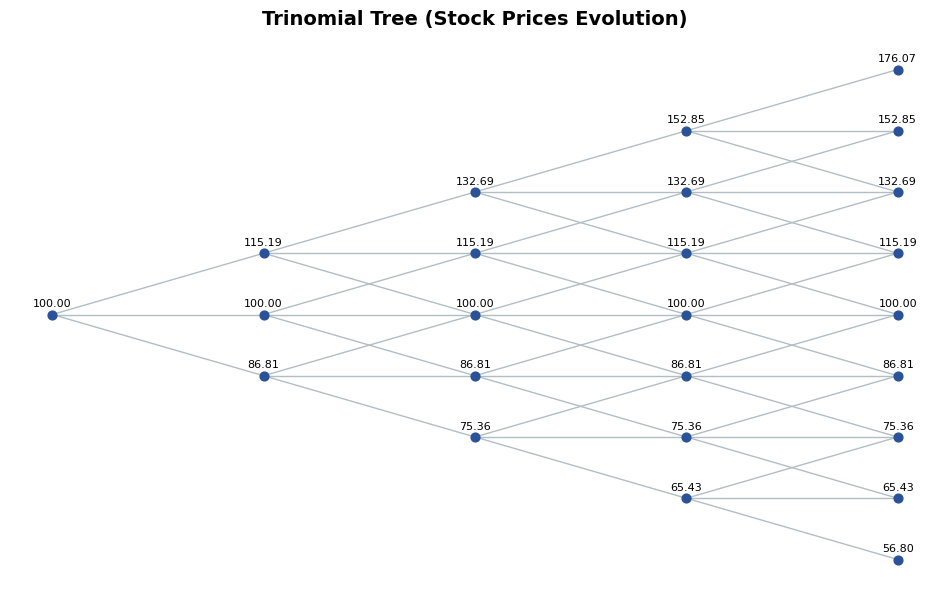

In [147]:

def plot_trinomial_tree(S, T, sigma, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt))
    d = 1 / u

    tree = []
    for i in range(N + 1):
        level = [S * (u**max(0, k - i)) * (d**max(0, i - k)) for k in range(2 * i + 1)]
        tree.append(level)

    fig, ax = plt.subplots(figsize=(12, 7))

    for i in range(len(tree)):
        for j in range(len(tree[i])):
            x = i
            y = j - i
            ax.scatter(x, y, color='#2a5298', s=40, zorder=3)
            ax.text(x, y + 0.1, f"{tree[i][j]:.2f}", fontsize=8,
                    ha='center', va='bottom', zorder=4)

            if i < N:
                ax.plot([x, x+1], [y, (j+2) - (i+1)], color='#b2bec3', linestyle='-', lw=1, zorder=1)
                ax.plot([x, x+1], [y, (j+1) - (i+1)], color='#b2bec3', linestyle='-', lw=1, zorder=1)
                ax.plot([x, x+1], [y, j - (i+1)], color='#b2bec3', linestyle='-', lw=1, zorder=1)

    ax.set_title("Trinomial Tree (Stock Prices Evolution)", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Time Step (N)", fontsize=11)
    ax.axis('off')
    plt.show()

plot_trinomial_tree(S=100, T=1, sigma=0.2, N=4)

### 2. Bjerksund & Stensland (2002) Approximation Model

The Bjerksund and Stensland, 1993 approximation can be used to price American options on stocks, futures and currencies. Bjerksund and Stensland's approximation is based on an exercise strategy corresponding to a flat boundary I (trigger price). 

The Bjerksund and Stensland (2002) approximation improves the 1993 model by replacing the single constant exercise boundary with a two-boundary optimal exercise strategy. This leads to a significantly more accurate representation of the American option free boundary, especially for dividend-paying assets.

Instead of assuming a single trigger level $I$, the model splits the remaining life of the option into two regimes and approximates optimal exercise using two time-dependent boundaries. Given this feasible but non-optimal strategy, the American call boils down to: 
- European-style valuation terms
- Early exercise premium contributions over two regions
- Joint survival (non-exercise) probabilities

Define the split point:

$$t_1 = \frac{\sqrt{5}-1}{2}T$$

The exercise strategy is approximated by:
- A first boundary $B_1$ active in $[0,t_1]$
- A second boundary $B_2$ active in $[t_1,T]$

This structure better approximates the true free boundary of the American option, which is time-dependent.

Their American call approximation is:

$$c = \alpha(X)S^{\beta}-\alpha(X)\varphi(S,t|\beta,X,X) +\varphi(S,t|1,X,X)-\varphi(S,t|1,x,X) -K\varphi(S,t|0,X,X)+K\varphi(S,t|0,x,X) +\alpha(x)\varphi(S,t|\beta,x,X) -$$
$$-\alpha(x)\Psi(S,T|\beta,x,X,x,t) +\Psi(S,T|1,x,X,x,t)-\Psi(S,T|1,K,X,x,t) -K\Psi(S,T|0,x,X,x,t)+K\Psi(S,T|0,K,X,x,t)$$

where:

$$\alpha(X) = (X-K)X^{-\beta}$$
$$\beta = (\frac{1}{2}-\frac{b}{\sigma^{2}})+\sqrt{(\frac{b}{\sigma^{2}}-\frac{1}{2})^{2}+2\frac{r}{\sigma^{2}}}$$

And the function $\phi(S, T|\gamma, H, X)$ is given by:

$$\phi(S,T|\gamma,H,X) = e^{\lambda T}S^{\gamma}[N(-\frac{ln(S/H)+(b+(\gamma-\frac{1}{2})\sigma^{2})T}{\sigma\sqrt{T}}) - (\frac{X}{S})^{\kappa}N(-\frac{ln(X^{2}/(SH))+(b+(\gamma-\frac{1}{2})\sigma^{2})T}{\sigma\sqrt{T}})]$$

where

$$\lambda = -r+\gamma b+\frac{1}{2}\gamma(\gamma-1)\sigma^{2}$$
$$\kappa = \frac{2b}{\sigma^{2}}+(2\gamma-1)$$

Evaluates via the standard bivariate normal distribution function $M(\cdot,\cdot;\cdot)$, the two-step joint expectation function $\Psi(S,T|\gamma,H,X,x,t)$ is written as:

$$\begin{aligned}
\Psi(S,T|\gamma,H,X,x,t) &=\exp\{\lambda T\}S^{\gamma}\Bigg\{M\left(d_{1},D_{1};\sqrt{\frac{t}{T}}\right)-\left(\frac{X}{S}\right)^{\kappa}M\left(d_{2},D_{2};\sqrt{\frac{t}{T}}\right) \\
&\quad-\left(\frac{x}{S}\right)^{\kappa}M\left(d_{3},D_{3};-\sqrt{\frac{t}{T}}\right)+\left(\frac{x}{X}\right)^{\kappa}M\left(d_{4},D_{4};-\sqrt{\frac{t}{T}}\right)\Bigg\}
\end{aligned}$$

where

$$d_{1}=-\frac{\ln(S/x)+\left(b+\left(\gamma-\frac{1}{2}\right)\sigma^{2}\right)t}{\sigma\sqrt{t}}$$
$$d_{2}=-\frac{\ln(X^{2}/(Sx))+\left(b+\left(\gamma-\frac{1}{2}\right)\sigma^{2}\right)t}{\sigma\sqrt{t}}$$
$$d_{3}=-\frac{\ln(S/x)-\left(b+\left(\gamma-\frac{1}{2}\right)\sigma^{2}\right)t}{\sigma\sqrt{t}}$$
$$d_{4}=-\frac{\ln(X^{2}/(Sx))-\left(b+\left(\gamma-\frac{1}{2}\right)\sigma^{2}\right)t}{\sigma\sqrt{t}}$$

are the Normal Integral Limits for First Period ($d_1$ to $d_4$) and

$$D_{1}=-\frac{\ln(S/H)+\left(b+\left(\gamma-\frac{1}{2}\right)\sigma^{2}\right)T}{\sigma\sqrt{T}}$$
$$D_{2}=-\frac{\ln(X^{2}/(SH))+\left(b+\left(\gamma-\frac{1}{2}\right)\sigma^{2}\right)T}{\sigma\sqrt{T}}$$
$$D_{3}=-\frac{\ln(x^{2}/(SH))+\left(b+\left(\gamma-\frac{1}{2}\right)\sigma^{2}\right)T}{\sigma\sqrt{T}}$$
$$D_{4}=-\frac{\ln((Sx^{2})/(HX^{2}))+\left(b+\left(\gamma-\frac{1}{2}\right)\sigma^{2}\right)T}{\sigma\sqrt{T}}$$

are the Normal Integral Limits for Second Period ($D_1$ to $D_4$).

The Golden Rule Split Parameter ($t$)

Determines the optimal point to step down the exercise boundary based on the golden ratio rule:
$$t=\frac{1}{2}(\sqrt{5}-1)T$$

The corresponding flat boundary approximations assigned to the two discrete phases:
$$X=X_{T}$$
$$x=X_{T-t}$$

where

$$X_{T}=B_{0}+(B_{\infty}-B_{0})(1-\exp\{h(T)\})$$
$$h(T)=-(bT+2\sigma\sqrt{T})(\frac{K^{2}}{(B_{\infty}-B_{0})B_{0}})$$
$$B_{\infty}\equiv\frac{\beta}{\beta-1}K$$
$$B_{0}\equiv \max\left\{K,\left(\frac{r}{r-b}\right)K\right\}$$

To price an American put option under this framework, the paper dictates using the Bjerksund and Stensland put-call transformation formula:
$$p(S,K,T,r,b,\sigma)=c(K,S,T,r-b,-b,\sigma)$$

In [148]:

def bjerksund_stensland_2002(S, K, T, r, sigma, option_type="call", q=0.0):
    # 1. Handle Put-Call Symmetry Transformation (Eq. 19)
    if option_type == "put":
        # Invert S and K, swap r and q (equivalent to r - b transformation)
        return bjerksund_stensland_2002(S=K, K=S, T=T, r=q, sigma=sigma, option_type="call", q=r)
    
    if T <= 0:
        return max(S - K, 0)
    
    b = r - q
    # If cost of carry b >= r (i.e. q <= 0), early exercise of a call is never optimal
    if b >= r:
        return black_scholes(S, K, T, r, sigma, "call", q)
    
    # 2. Key components from Eq. (5) & (6)
    beta = (0.5 - b / sigma**2) + np.sqrt((b / sigma**2 - 0.5)**2 + 2 * r / sigma**2)
    
    # Infinite and immediate boundary levels (Eq. 12 & 13)
    B_infinity = (beta / (beta - 1)) * K
    B_0 = max(K, (r / (r - b)) * K)
    
    # Internal helper to find the boundary X_T (Eq. 10 & 11)
    def get_boundary(time_to_mat):
        h_t = -(b * time_to_mat + 2 * sigma * np.sqrt(time_to_mat)) * (K**2 / ((B_infinity - B_0) * B_0))
        return B_0 + (B_infinity - B_0) * (1 - np.exp(h_t))
    
    # Determine step times and boundaries using the Golden Rule (Eq. 16, 17, 18)
    t = 0.5 * (np.sqrt(5) - 1) * T
    X = get_boundary(T)      # Boundary for period [0, t)
    x = get_boundary(T - t)  # Boundary for period [t, T]
    
    # Check for immediate exercise triggers
    if S >= X:
        return S - K

    # Helper function 1: Single barrier survival expectation phi (Eq. 7, 8, 9)
    def phi(S, time, gamma, H, barrier):
        lambda_val = -r + gamma * b + 0.5 * gamma * (gamma - 1) * sigma**2
        kappa = (2 * b / sigma**2) + (2 * gamma - 1)
        
        d1 = -(np.log(S / H) + (b + (gamma - 0.5) * sigma**2) * time) / (sigma * np.sqrt(time))
        d2 = -(np.log(barrier**2 / (S * H)) + (b + (gamma - 0.5) * sigma**2) * time) / (sigma * np.sqrt(time))
        
        return np.exp(lambda_val * time) * (S**gamma) * (norm.cdf(d1) - (barrier / S)**kappa * norm.cdf(d2))

    # Helper function 2: Two-step joint barrier survival expectation Psi (Prop 1 / App B)
    def psi(S, T, gamma, H, X, x, t):
        lambda_val = -r + gamma * b + 0.5 * gamma * (gamma - 1) * sigma**2
        kappa = (2 * b / sigma**2) + (2 * gamma - 1)
        rho = np.sqrt(t / T)
        
        # Calculate localized vector limits for first period (d) and second period (D)
        drift_term_t = (b + (gamma - 0.5) * sigma**2) * t
        drift_term_T = (b + (gamma - 0.5) * sigma**2) * T
        
        d1 = -(np.log(S / x) + drift_term_t) / (sigma * np.sqrt(t))
        d2 = -(np.log(X**2 / (S * x)) + drift_term_t) / (sigma * np.sqrt(t))
        d3 = -(np.log(S / x) - drift_term_t) / (sigma * np.sqrt(t))
        d4 = -(np.log(X**2 / (S * x)) - drift_term_t) / (sigma * np.sqrt(t))
        
        D1 = -(np.log(S / H) + drift_term_T) / (sigma * np.sqrt(T))
        D2 = -(np.log(X**2 / (S * H)) + drift_term_T) / (sigma * np.sqrt(T))
        D3 = -(np.log(x**2 / (S * H)) + drift_term_T) / (sigma * np.sqrt(T))
        D4 = -(np.log((S * x**2) / (H * X**2)) + drift_term_T) / (sigma * np.sqrt(T))
        
        # Standard structural covariance configurations
        cov_pos = np.array([[1.0, rho], [rho, 1.0]])
        cov_neg = np.array([[1.0, -rho], [-rho, 1.0]])
        
        m1 = multivariate_normal.cdf([d1, D1], cov=cov_pos)
        m2 = multivariate_normal.cdf([d2, D2], cov=cov_pos)
        m3 = multivariate_normal.cdf([d3, D3], cov=cov_neg)
        m4 = multivariate_normal.cdf([d4, D4], cov=cov_neg)
        
        return np.exp(lambda_val * T) * (S**gamma) * (m1 - (X / S)**kappa * m2 - (x / S)**kappa * m3 + (x / X)**kappa * m4)

    # 4. Synthesize Option Price components from Proposition 1
    alpha_X = (X - K) * (X**(-beta))
    alpha_x = (x - K) * (x**(-beta))
    
    # First step barrier portfolio components
    price = alpha_X * S**beta - alpha_X * phi(S, t, beta, X, X) + phi(S, t, 1, X, X) - phi(S, t, 1, x, X) - K * phi(S, t, 0, X, X) + K * phi(S, t, 0, x, X) + alpha_x * phi(S, t, beta, x, X)
    
    # Second step joint barrier portfolio components
    price = price - alpha_x * psi(S, T, beta, x, X, x, t) + psi(S, T, 1, x, X, x, t) - psi(S, T, 1, K, X, x, t) \
            - K*psi(S, T, 0, x, X, x, t) + K * psi(S, T, 0, K, X, x, t)
    
    return max(price, S - K)

### 3. Least-Squares Monte Carlo (LSMC) under Stochastic Volatility (Heston)

The Least-Squares Monte Carlo (LSMC) method, introduced by Francis Longstaff and Eduardo Schwartz in 2001, is a standard numerical technique in quantitative finance used to value American-style derivatives. It solves the problem of early exercise by combining Monte Carlo simulation with least-squares regression to determine the optimal exercise strategy.

While traditionally implemented under a constant volatility (Black-Scholes) framework, LSMC can be generalized to stochastic volatility environments, such as the Heston model, to capture the volatility smile. In this setup, the continuation value depends on a multidimensional state space composed of both the underlying asset price ($S_t$) and its variance ($v_t$).The LSMC algorithm operates backward in time, assuming that exercise decisions can only happen at a discrete set of dates $t_1, t_2, \dots, t_{N-1}$:
- 1. Path Generation: Simulate multiple random paths simultaneously for both the underlying asset price ($S$) and its variance ($v$) from the present to the maturity date $T$ using an Euler-Maruyama or Full Truncation scheme. To account for the asset's dividend yield ($q$), the asset's risk-neutral drift is adjusted to $r - q$.
- 2. Terminal Payoffs: At the final exercise date $t_{N}$, calculate the payoff for every path based on the terminal asset price $S_{t_N}$.
- 3. Backward Induction: For each preceding date $t_{i}$ (working backward from $t_{N-1}$ to $t_1$):
        - Identify In-the-Money Paths: Filter only the paths where the option is currently in-the-money (immediate exercise yields a positive value).
        - Multidimensional Regression: Set up a regression where the realized future cash flows (discounted back to $t_{i}$) are regressed against a two-dimensional set of state variables representing the asset price and variance ($S_{t_i}$ and $v_{t_i}$). The basis functions must be adapted to capture joint cross-effects, typically using a bivariate polynomial basis (e.g., $[1, S, v, S^2, v^2, S \cdot v]$).
        - Continuation Value: The fitted value from this regression provides an estimate of the continuation value of holding the option given the joint state $(S_{t_i}, v_{t_i})$.
        - Exercise Decision: Compare the immediate exercise value to the estimated continuation value. If immediate exercise is more profitable, the option is exercised at $t_{i}$, and that path’s cash flow history is updated.
- 4. Final Valuation: Average the discounted cash flows across all simulated paths back to $t_0$ to determine the current option price.

**Advantages**

- High-Dimensional Capability: Unlike traditional lattice methods (binomial trees) or finite difference equations, LSMC scales well and can easily handle options dependent on multiple underlying assets or multidimensional state spaces (Price + Volatility).
- Flexibility: It easily incorporates path-dependent features, dividends, and complex stochastic volatility or interest rate models.

**Limitations**

- Look-Ahead Bias: Because the optimal exercise rule is derived from the same paths used to value the option, a slight look-ahead bias can occur, though this can be mitigated using independent paths for validation.
- Basis Functions (Curse of Dimensionality): The accuracy of the method highly depends on the chosen basis functions. Expanding the state space to include variance ($v$) increases the required number of cross-terms in the regression, making the choice of basis functions critical to avoid underfitting or regression overfitting.

In [149]:

def longstaff_schwartz_heston_american(S0, K, T, r, v0, kappa, theta, sigma_v, rho, steps=200, paths=100000, option_type="call", q=0.0):
    dt = T / steps
    df = np.exp(-r * dt)
    
    # 1. Definir la función de payoff según el tipo de opción
    option_type = option_type.lower()
    if option_type == 'call':
        payoff_func = lambda s: np.maximum(s - K, 0)
    else:
        payoff_func = lambda s: np.maximum(K - s, 0)
    
    # 2. Simulación de caminos acoplados (Heston con Dividend Yield 'q')
    S = np.zeros((steps + 1, paths))
    v = np.zeros((steps + 1, paths))
    S[0, :] = S0
    v[0, :] = v0
    
    # Correlación usando la descomposición de Cholesky
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    
    for t in range(steps):
        # Generar ruidos correlacionados para los M caminos
        Z = np.random.multivariate_normal(mean, cov, paths).T
        Z_S, Z_v = Z[0], Z[1]
        
        v_plus = np.maximum(v[t, :], 0)
        
        # Simulación de Varianza (Esquema Full Truncation)
        v[t+1, :] = v[t, :] + kappa * (theta - v_plus) * dt + sigma_v * np.sqrt(v_plus) * np.sqrt(dt) * Z_v
        
        # Simulación de Precio incluyendo el Dividend Yield (q) en el drift
        S[t+1, :] = S[t, :] * np.exp((r - q - 0.5 * v_plus) * dt + np.sqrt(v_plus) * np.sqrt(dt) * Z_S)
        
    v = np.maximum(v, 0)
    
    # 3. Inducción hacia atrás de Longstaff-Schwartz
    cash_flows = payoff_func(S[-1, :]) # Pagos en el vencimiento T
    
    for t in range(steps - 1, 0, -1):
        X_S = S[t, :]
        X_v = v[t, :]
        exercise_value = payoff_func(X_S)
        
        # Filtrar solo los caminos que están In-the-Money (ITM)
        itm = exercise_value > 0
        
        if np.sum(itm) > 0:
            # Construir la base polinómica bidimensional para los caminos ITM
            # Términos esenciales: [1, S, v, S^2, v^2, S*v]
            S_itm = X_S[itm]
            v_itm = X_v[itm]
            
            A = np.vstack([np.ones_like(S_itm), S_itm, v_itm, S_itm**2, v_itm**2, S_itm * v_itm]).T
            Y = cash_flows[itm] * df
            
            # Regresión por mínimos cuadrados
            coeffs = np.linalg.lstsq(A, Y, rcond=None)[0]
            
            # Estimar el valor de continuación (esperable)
            continuation_value = A @ coeffs
            
            # Decisión de ejercicio anticipado
            exercise = exercise_value[itm] > continuation_value
            
            # Actualizar flujos de caja de los caminos donde decidimos ejercer
            itm_indices = np.where(itm)[0]
            exercise_indices = itm_indices[exercise]
            
            cash_flows[exercise_indices] = exercise_value[exercise_indices]
            
            # Los caminos que decidieron NO ejercer simplemente arrastran el descuento temporal
            non_exercise_indices = np.setdiff1d(np.arange(paths), exercise_indices)
            cash_flows[non_exercise_indices] *= df
        else:
            cash_flows *= df
            
    # Descuento final hasta el momento t=0
    return np.mean(cash_flows * df)


<>:74: SyntaxWarning: invalid escape sequence '\h'
<>:74: SyntaxWarning: invalid escape sequence '\h'
C:\Users\i001610\AppData\Local\Temp\ipykernel_14004\921625763.py:74: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(X_sort, Y_curve, color='darkblue', linewidth=3, label='Estimated Continuation Value $\hat{V}(S)$')


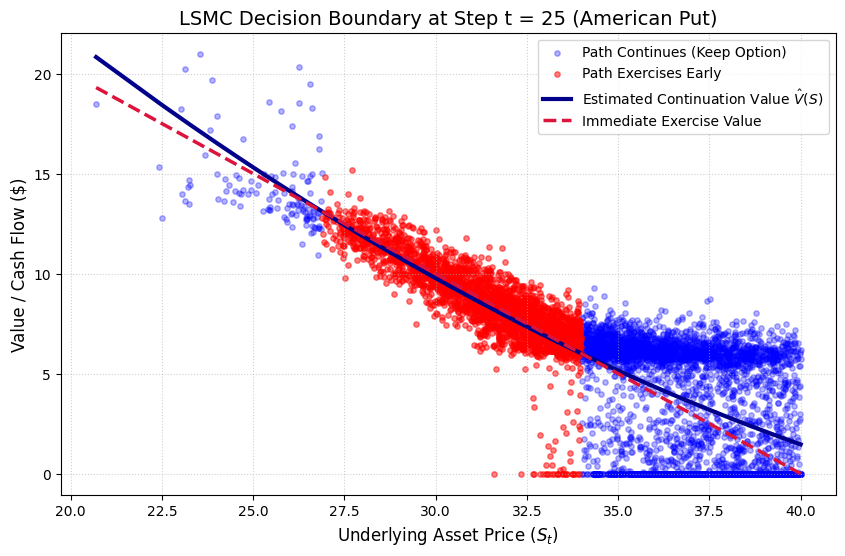

nan

In [150]:
def visualize_longstaff_schwartz(S, K, T, r, sigma, steps=50, paths=5000, option_type="put", q=0.0, plot_step=25):
    dt = T / steps
    df = np.exp(-r * dt)
    
    # 1. Path simulation
    X = np.zeros((steps + 1, paths))
    X[0] = S
    for t in range(1, steps + 1):
        Z = np.random.standard_normal(paths)
        X[t] = X[t-1] * np.exp((r - q - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
        
    # 2. Payoffs Matrix
    if option_type == "call":
        payoffs = np.maximum(X - K, 0)
    else:
        payoffs = np.maximum(K - X, 0)
        
    cash_flows = np.copy(payoffs[-1])
    
    # Storage variables for the specific step we want to plot
    saved_data = {}

    # 3. Backward induction loop
    for t in range(steps - 1, 0, -1):
        itm_paths = np.where(payoffs[t] > 0)[0]
        
        if len(itm_paths) > 0:
            X_itm = X[t, itm_paths]
            Y_continuation = cash_flows[itm_paths] * df
            
            poly_fit = np.polyfit(X_itm, Y_continuation, deg=2)
            value_continuation_pred = np.polyval(poly_fit, X_itm)
            value_exercise = payoffs[t, itm_paths]
            
            exercise_now = np.where(value_exercise > value_continuation_pred)[0]
            executed_paths = itm_paths[exercise_now]
            
            # --- CAPTURE DATA FOR VISUALIZATION ---
            if t == plot_step:
                saved_data = {
                    'X_itm': X_itm,
                    'Y_continuation': Y_continuation,
                    'poly_fit': poly_fit,
                    'exercise_now_mask': value_exercise > value_continuation_pred,
                    'value_exercise': value_exercise
                }
            
            # Update cash flows
            cash_flows[executed_paths] = value_exercise[exercise_now]
            
            # CRITICAL FIX for your original script:
            # Only non-executed paths carry forward discounted future values.
            # Your original code discounted non-executed paths twice if they didn't exercise.
            non_executed_paths = np.setdiff1d(np.arange(paths), executed_paths)
            cash_flows[non_executed_paths] *= df
        else:
            cash_flows *= df
            
    # --- GENERATE PLOT ---
    if saved_data:
        plt.figure(figsize=(10, 6))
        
        X_itm = saved_data['X_itm']
        Y_cont = saved_data['Y_continuation']
        mask = saved_data['exercise_now_mask']
        
        # 1. Plot actual realized future cash flows (noisy data points)
        plt.scatter(X_itm[~mask], Y_cont[~mask], color='blue', alpha=0.3, label='Path Continues (Keep Option)', s=15)
        plt.scatter(X_itm[mask], Y_cont[mask], color='red', alpha=0.5, label='Path Exercises Early', s=15)
        
        # 2. Plot the fitted regression curve (Continuation Value)
        X_sort = np.sort(X_itm)
        Y_curve = np.polyval(saved_data['poly_fit'], X_sort)
        plt.plot(X_sort, Y_curve, color='darkblue', linewidth=3, label='Estimated Continuation Value $\hat{V}(S)$')
        
        # 3. Plot the Intrinsic Exercise Value curve
        if option_type == "put":
            Y_exercise_curve = np.maximum(K - X_sort, 0)
        else:
            Y_exercise_curve = np.maximum(X_sort - K, 0)
        plt.plot(X_sort, Y_exercise_curve, color='crimson', linestyle='--', linewidth=2.5, label='Immediate Exercise Value')
        
        # Formatting
        plt.title(f"LSMC Decision Boundary at Step t = {plot_step} (American {option_type.capitalize()})", fontsize=14)
        plt.xlabel("Underlying Asset Price ($S_t$)", fontsize=12)
        plt.ylabel("Value / Cash Flow ($)", fontsize=12)
        plt.legend(loc='upper right', fontsize=10)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()

    return np.nan

# Run the visualization for an In-The-Money American Put
visualize_longstaff_schwartz(S=36, K=40, T=1.0, r=0.06, sigma=0.2, steps=50, paths=10000, option_type="put", plot_step=25)


### 4. Greeks

To calculate the Greeks (Delta, Gamma, Vega, Theta, and Rho) for an American option, standard analytical formulas like Black-Scholes cannot be used because they do not account for the early exercise feature. Instead, you must rely on numerical methods such as the "Bumping" Method.

**Delta:** $\Delta \approx \frac{V(S + \Delta S) - V(S - \Delta S)}{2 \Delta S}$

**Gamma:** $\Gamma \approx \frac{V(S + \Delta S) - 2V(S) + V(S - \Delta S)}{(\Delta S)^2}$

**Vega:** $\nu \approx \frac{V(\sigma + \Delta \sigma) - V(\sigma - \Delta \sigma)}{2 \Delta \sigma}$

**Theta:** $\Theta \approx \frac{V(t + \Delta t) - V(t)}{\Delta t}$ 

**Rho:** $\rho \approx \frac{V(r + \Delta r) - V(r - \Delta r)}{2 \Delta r}$

In [151]:
def american_greeks_svi(S, K, T, r, sigma, N, option_type, q):
    # Base Price
    V_base = trinomial_option_american(S, K, T, r, sigma, N, option_type, q)
    
    # Define Small Bumps
    dS = 0.01 * S
    dr = 0.0001        # 1 basis point
    dt = 1.0 / 365.25  # 1 day time bump
    
    # 1. Delta & Gamma (Bump Spot Up and Down)
    V_S_up   = trinomial_option_american(S + dS, K, T, r, sigma, N, option_type, q)
    V_S_down = trinomial_option_american(S - dS, K, T, r, sigma, N, option_type, q)
    
    delta = (V_S_up - V_S_down) / (2 * dS)
    gamma = (V_S_up - 2 * V_base + V_S_down) / (dS ** 2)
    
    # 2. Rho (Bump Interest Rate Up and Down)
    V_r_up   = trinomial_option_american(S, K, T, r + dr, sigma, N, option_type, q)
    V_r_down = trinomial_option_american(S, K, T, r - dr, sigma, N, option_type, q)
    
    rho = (V_r_up - V_r_down) / (2 * dr)
    
    # 3. Vega (Parallel shift in SVI smile via 'a' parameter)
    dsigma = 0.01 * sigma
    V_veg_up = trinomial_option_american(S, K, T, r, sigma + dsigma, N, option_type, q)
    V_veg_dn = trinomial_option_american(S, K, T, r, sigma - dsigma, N, option_type, q)
    
    vega = (V_veg_up - V_veg_dn) / (2 * dsigma)
    
    # 4. Theta (Decrease Time to Maturity by 1 day)
    # If option has less than 1 day to live, we avoid negative time
    T_w_decay = max(T - dt, 0.0001) 
    V_time_decay = trinomial_option_american(S, K, T_w_decay, r, sigma, N, option_type, q)
    
    # Calculated as a daily rate (Option value tomorrow - Option value today)
    theta = V_time_decay - V_base
    
    return [delta, gamma, theta, vega, rho]


### 5. Principal Script

This analysis presents a comparative breakdown of American option prices and respective risk sensitivities (Greeks) for an at-the-money (ATM) option with a T-year maturity. The matrix evaluates pricing across five distinct quantitative frameworks, contrasting a non-dividend baseline against a continuous dividend yield.

In [152]:
# Define parameters
S = 100 # initial stock price
K = 100 # strike price
T = 1 # time to maturity
r = 0.05 # risk-free rate
sigma = 0.2 # implied volatility
q = 0.02 # continuous divident yield

kappa = 2.0 # Rate of mean reversion; the speed at which volatility reverts to its long-term average
theta = 0.05 # Long-term average variance (i.e., the long-term mean of the volatility squared)
ssigma = 0.4 # Volatility of volatility ("vol of vol"); describes how much the variance fluctuates.
rho = -0.7 # Correlation between the stock price and the variance (usually negative for equities to reflect leverage)
v0 = 0.04 # Current/Initial instantaneous variance of the underlying asset

print(f"Parameters: \n - Initial stock price: {S} \n - Strike price: {K} \n - Time to Maturity: {T} \n - Risk-free Rate: {r} \n - Implied Volatility: {sigma} \n - Continuous divident yield: {q}")
print(f" - Rate of mean reversion: {kappa} \n - Long-term average variance: {theta} \n - Volatility of volatility {ssigma} \n - Correlation between the stock price and the variance: {rho} \n - Instantaneous variance of the underlying asset: {v0} \n")

call_greeks = american_greeks_svi(S, K, T, r, sigma, N=100, option_type="call", q=0.0)
call_greeks_divident = american_greeks_svi(S, K, T, r, sigma, N=100, option_type="call", q=q)
put_greeks = american_greeks_svi(S, K, T, r, sigma, N=100, option_type="put", q=0.0)
put_greeks_divident = american_greeks_svi(S, K, T, r, sigma, N=100, option_type="put", q=q)

df_greeks = pd.DataFrame({
    " ": ["Trinomial Model Pricing", "Bjerksund Stensland Pricing", "Longstaff Schwartz Pricing", 
          "Greek: Delta", "Greek: Gamma", "Greek: Theta", "Greek: Vega", "Greek: Rho"],
    "Call Option": [
        trinomial_option_american(S, K, T, r, sigma, option_type="call"),
        bjerksund_stensland_2002(S, K, T, r, sigma, option_type="call"),
        longstaff_schwartz_heston_american(S, K, T, r, v0, kappa, theta, ssigma, rho, steps=50, paths=10000, option_type="call"),
        call_greeks[0],
        call_greeks[1],
        call_greeks[2],
        call_greeks[3],
        call_greeks[4]
    ],
    "Call Option With Dividend": [
        trinomial_option_american(S, K, T, r, sigma, option_type="call", q=q),
        bjerksund_stensland_2002(S, K, T, r, sigma, option_type="call", q=q),
        longstaff_schwartz_heston_american(S, K, T, r, v0, kappa, theta, ssigma, rho, steps=50, paths=10000, option_type="call", q=q),
        call_greeks_divident[0],
        call_greeks_divident[1],
        call_greeks_divident[2],
        call_greeks_divident[3],
        call_greeks_divident[4]
    ],
    "Put Option": [
        trinomial_option_american(S, K, T, r, sigma, option_type="put"),
        bjerksund_stensland_2002(S, K, T, r, sigma, option_type="put"),
        longstaff_schwartz_heston_american(S, K, T, r, v0, kappa, theta, ssigma, rho, steps=50, paths=10000, option_type="put"),
        put_greeks[0],
        put_greeks[1],
        put_greeks[2],
        put_greeks[3],
        put_greeks[4]
    ],
    "Put Option With Dividend": [
        trinomial_option_american(S, K, T, r, sigma, option_type="put", q=q),
        bjerksund_stensland_2002(S, K, T, r, sigma, option_type="put", q=q),
        longstaff_schwartz_heston_american(S, K, T, r, v0, kappa, theta, ssigma, rho, steps=50, paths=10000, option_type="put", q=q),
        put_greeks_divident[0],
        put_greeks_divident[1],
        put_greeks_divident[2],
        put_greeks_divident[3],
        put_greeks_divident[4]
    ]
})
pd.options.display.float_format = '{:.4f}'.format
print("Option Prices Comparison Table:")
print(df_greeks.to_string(index=False))

Parameters: 
 - Initial stock price: 100 
 - Strike price: 100 
 - Time to Maturity: 1 
 - Risk-free Rate: 0.05 
 - Implied Volatility: 0.2 
 - Continuous divident yield: 0.02
 - Rate of mean reversion: 2.0 
 - Long-term average variance: 0.05 
 - Volatility of volatility 0.4 
 - Correlation between the stock price and the variance: -0.7 
 - Instantaneous variance of the underlying asset: 0.04 

Option Prices Comparison Table:
                             Call Option  Call Option With Dividend  Put Option  Put Option With Dividend
    Trinomial Model Pricing      10.3513                     9.1304      6.0098                    6.5741
Bjerksund Stensland Pricing      10.4506                     9.2270      6.0448                    6.6292
 Longstaff Schwartz Pricing      10.7033                     9.2726      6.3999                    6.7712
               Greek: Delta       0.6367                     0.5867     -0.4114                   -0.4234
               Greek: Gamma       0.053

**Dashboard**

In [ ]:

# ==============================================================================
# 1. ENVOLVING FUNCTION (ORCHESTING THE DASHBOARD)
# ==============================================================================
def calcular_y_mostrar_dashboard(b=None):
    # To aboid duplicating the output 
    with output_area:
        clear_output(wait=True)
        
        ticker = txt_ticker.value.upper()
        T = float(num_T.value)
        
        print(f"Charging the data and calibrating the models for {ticker}... Please wait.")
        
        try:
            stock = yf.Ticker(ticker)
            hist = stock.history(period="3y")
            S = hist['Close'].dropna().iloc[-1]
            
            # Configuration of Strike Opcional (If 0 or blank -> ATM)
            K = float(num_K.value) if num_K.value > 0 else S
            
            # Risk Free Rate
            try:
                r = fred.get_series('DTB3').iloc[-1] / 100
            except:
                r = 0.045
            
            # Divident yield
            try:
                q = (stock.info.get('lastDividendValue', 0.25) * 4) / S
            except:
                q = 0.0
                
            # Implied volatility
            try:
                sigma_t1 = calculate_iv(calls1.iloc[(calls1['strike'] - S).abs().idxmin()]['lastPrice'], S, K, T, r, option_type='call', q=q)
                sigma_t2 = calculate_iv(calls2.iloc[(calls2['strike'] - S).abs().idxmin()]['lastPrice'], S, K, T, r, option_type='call', q=q)
                sigma = (sigma_t1 + sigma_t2) / 2.0

            except Exception:
                sigma = (np.log(hist['Close'] / hist['Close'].shift(1))).std() * np.sqrt(252)
            if np.isnan(sigma): sigma = (np.log(hist['Close'] / hist['Close'].shift(1))).std() * np.sqrt(252)
            
            # --- Heston Calibration ---
            initial_params = [2.0, 0.2, 0.3, -0.5, 0.04]
            bounds = [
                    (0.1, 10.0),                                      # kappa: mean reversion speed
                    (0.01, 1.0),                                      # theta bound centered on market
                    (0.01, 1.0),                                      # sigma_v: vol of vol
                    (-0.99, 0.99),                                    # rho: leverage effect (usually negative)
                    (0.01, 1)                                         # v0
                ]
            # Paso local con restricciones utilizando el algoritmo L-BFGS-B
            local_result = minimize(
                objective_function, x0=initial_params, method='L-BFGS-B', bounds=bounds, 
                args=(calls['lastPrice'].to_numpy(), calls['strike'].to_numpy(), calls['maturity'].to_numpy(), S, r, "call", q),
                options={'disp': True})
            k_cal, th_cal, sig_cal, rho_cal, v0_cal = local_result.x

            # ==================================================================
            # rEPORT OF THE rESULTS
            # ==================================================================
            clear_output() # Cleans the text of "Charging..."
            
            print(f"==========================================================")
            print(f" RESULTS OF CALIBRATION AND MARKET FOR {ticker}")
            print(f"==========================================================")
            print(f" - Spot Price (S): {S:.4f}   | - Strike (K): {K:.4f} {'(ATM)' if num_K.value==0 else ''}")
            print(f" - Risk-Free Rate (r): {r*100:.2f}%  | - Dividend Yield (q): {q*100:.2f}%")
            print(f" - Implied Vol (BS): {sigma*100:.2f}%   | - Time to Maturity (T): {T} year(s)\n")
            print(f" - Heston Parameters: κ={k_cal:.4f}, θ={th_cal:.4f}, σ_v={sig_cal:.4f}, ρ={rho_cal:.4f}, v0={v0_cal:.4f}")
            
            # --- Building the pricing table ---
            df_models = pd.DataFrame({
                "Pricing Model": [
                    "Trinomial Model", "Bjerksund Stensland", "Longstaff Schwartz Heston"
                ],
                "Call Option": [
                    trinomial_option_american(S, K, T, r, sigma, option_type="call", q=q),
                    bjerksund_stensland_2002(S, K, T, r, sigma, option_type="call", q=q),
                    longstaff_schwartz_heston_american(S, K, T, r, v0_cal, k_cal, th_cal, sig_cal, rho_cal, option_type="call", q=q)
                ],
                "Put Option": [
                    trinomial_option_american(S, K, T, r, sigma, option_type="put", q=q),
                    bjerksund_stensland_2002(S, K, T, r, sigma, option_type="put", q=q),
                    longstaff_schwartz_heston_american(S, K, T, r, v0_cal, k_cal, th_cal, sig_cal, rho_cal, option_type="put", q=q)
                ]
            })
            
            # Making the table
            pd.options.display.float_format = '{:.4f}'.format
            display(df_models)

            print("\n")

            call_greeks_divident = american_greeks_svi(S, K, T, r, sigma, N=100, option_type="call", q=q)
            put_greeks_divident = american_greeks_svi(S, K, T, r, sigma, N=100, option_type="put", q=q)

            # Greeks table
            df_greeks = pd.DataFrame({
                "Greek (base on TT Model)": [
                    "Delta", "Gamma", "Theta", "Vega", "Rho"
                ],
                "Call Option": [
                    call_greeks_divident[0],
                    call_greeks_divident[1],
                    call_greeks_divident[2],
                    call_greeks_divident[3],
                    call_greeks_divident[4]
                ],
                "Put Option": [
                    put_greeks_divident[0],
                    put_greeks_divident[1],
                    put_greeks_divident[2],
                    put_greeks_divident[3],
                    put_greeks_divident[4]
                ]
            })
            
            # Making the table
            pd.options.display.float_format = '{:.4f}'.format
            display(df_greeks)
            
        except Exception as e:
            print(f"ERROR processing the dashboard: {e}")

# ==============================================================================
# 2. CREATING THE VISUAL COMPONENTS (WIDGETS)
# ==============================================================================
txt_ticker = widgets.Text(value='SPY', description='Ticker:', style={'description_width': 'initial'})
num_T = widgets.FloatText(value=1.0, description='Maturity (T in years):', style={'description_width': 'initial'})
num_K = widgets.FloatText(value=np.nan, description='Strike K (blank for ATM):', style={'description_width': 'initial'})

btn_calcular = widgets.Button(description='Calculate', button_style='success', font_weight='bold')
btn_calcular.style.font_weight = 'bold'
output_area = widgets.Output()

# Linking the click of the button to the execution function
btn_calcular.on_click(calcular_y_mostrar_dashboard)

# ==============================================================================
# 3. BUILDING THE VISUAL OF THE DASHBOARD
# ==============================================================================
# Putting the controls in a horizontal box and below the output area for the data
controles = widgets.HBox([txt_ticker, num_T, num_K, btn_calcular])
dashboard = widgets.VBox([controles, output_area])

# Renderizing the full Dashboard in the notebook
display(dashboard)

C:\Users\i001610\AppData\Roaming\Python\Python313\site-packages\jupyter_client\session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


## Pricing Exotic Options

Exotic options are complex, non-standard financial derivatives that offer customized payoff structures, strike prices, or expiration conditions. Unlike traditional "vanilla" call or put options traded on public exchanges, exotics are typically traded over-the-counter (OTC) between institutional investors or highly sophisticated market participants.

In this section it will be exposed and price-modeled the following Exotic Option types: 
- Asian Options
- Barrier Options
- Binary Options
- Gap Opions
- Forward Start Options
- Compound Options
- Chooser Options
- Lookback Options

### 1. Asian Options

An Asian option is a type of option contract whose payoff is based on the average price of the underlying asset over a set period of time. Unlike standard American or European options, which depend on the asset's price at a specific moment, Asian options use an average price, usually calculated using arithmetic or geometric methods.

**European Asian Call and Put Options with Geometric Averaging**

We are able to derive a closed-form solution for the geometric Asian option.

Now it is possible the calculate the value of the European Asian call with geometric averaging. At this point, it is useful to define:
$$\sigma_G = \frac{\sigma}{\sqrt{3}}$$
$$b = \frac{1}{2} (r - q - \frac{1}{2}\sigma_G^2)$$
$$d_1 = \frac{log(\frac{S_0}{K}) + (b + \frac{1}{2}\sigma_G^2)T}{\sigma_G\sqrt{T}}$$
$$d_2 = d_1 - \sigma_G \sqrt{T}$$

Going through the same process as is done with the Black-Scholes model, we are able to find that:
$$C_G = S_0 e^{(b-r)T}\Phi(d_1) - Ke^{-rT}\Phi(d_2)$$

In fact, going through the same arguments for the European Asian put with geometric averaging $P_G$, we find that:
$$P_G = Ke^{-rT}\Phi(-d_2) - S_0 e^{(b-r)T}\Phi(-d_1)$$

where

- $\Phi$ denotes the cumulative distribution function of the normal distribution.

**European Asian Call and Put Options with Arithmetic Averaging**

Turnbull-Wakeman Approximation. This model matches the first two statistical moments of the arithmetic average to an adjusted lognormal distribution. It modifies the standard Black-Scholes parameters to calculate an analytical price.
$$b = r-q$$
$$M_1 =
\begin{cases}
\dfrac{S_0\left(e^{bT}-1\right)}{bT}, & b \neq 0, \\[1ex]
S_0, & b = 0.
\end{cases}$$

$$M_2 =
\begin{cases}
\displaystyle
\frac{2S_0^2}{T^2}[\frac{e^{(2b+\sigma^2)T}}{(b+\sigma^2)(2b+\sigma^2)} + \frac{1}{b} (\frac{1}{2b+\sigma^2} - \frac{e^{bT}}{b+\sigma^2})],
& b\neq0,
\\[3ex]
\displaystyle
\frac{2S_0^2}{T^2}[\frac{e^{\sigma^2T}-1}{\sigma^4} - \frac{T}{\sigma^2}],
& b=0.
\end{cases}$$

Adjusted Volatility $(\sigma _{A})$: $\sigma_A = \sqrt{\frac{1}{T} \ln(\frac{M_2}{M_1^2})}$

Adjusted Dividend Yield $(q_{A})$: $q_A = r - \frac{1}{T} \ln(\frac{M_1}{S_0})$

You plug these adjusted values directly into the standard Black-Scholes formula.

In [154]:

def european_asian_options(S, K, T, r, sigma, option_type="call", average_type="G", q=0.0):
    
    if average_type=="G":
        sigmaG = sigma/np.sqrt(3)
        b = 0.5 * (r - q - 0.5*sigmaG**2)
        d1 = (np.log(S/K) + (b + 0.5*sigmaG**2)*T) / (sigmaG * np.sqrt(T))
        d2 = d1 - sigmaG*np.sqrt(T)
        
        if option_type=="call":
            option_price = S * np.exp((b-r)*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
        else:
            option_price = K*np.exp(-r*T)*norm.cdf(-d2) - S * np.exp((b-r)*T)*norm.cdf(-d1)
    else:
        b = r-q

        if abs(b)<10e-8: m1 = S
        else: m1 = (np.exp(b*T) - 1) * S / (b*T)

        if abs(b)<10e-8: m2 = ((2 * S**2) / T**2) * (((np.exp(T*sigma**2)-1) / (sigma**4)) - ((T) / (sigma**2)))
        else: m2 = ((2 * S**2) / T**2) * ((np.exp((2*b+sigma**2)*T) / ((b+sigma**2)*(2*b+sigma**2))) + (1/b) * ((1/(2*b+sigma**2)) - (np.exp(b*T)/(b+sigma**2))))
        
        sigmaA = np.sqrt((1/T) * np.log(m2/m1**2))
        qA = r - (1/T) * np.log(m1/S)
        
        if option_type=="call":
            option_price = black_scholes(S, K, T, r, sigmaA, option_type="call", q=qA)
        else:
            option_price = black_scholes(S, K, T, r, sigmaA, option_type="put", q=qA)

    return option_price


In [155]:
# Define parameters
S = 100 # initial stock price
K = 100 # strike price
T = 1 # time to maturity
r = 0.05 # risk-free rate
sigma = 0.2 # implied volatility
q = 0.02 # continuous divident yield

print(f"Parameters: \n - Initial stock price: {S} \n - Strike price: {K} \n - Time to Maturity: {T} \n - Risk-free Rate: {r} \n - Implied Volatility: {sigma} \n - Continuous divident yield: {q} \n")

df_greeks = pd.DataFrame({
    " ": ["Geometric Averaging", "Arithmetic Averaging"],
    "Call Option": [
        european_asian_options(S, K, T, r, sigma, option_type="call", average_type="G", q=q),
        european_asian_options(S, K, T, r, sigma, option_type="call", average_type="A", q=q)
    ],
    "Put Option": [
        european_asian_options(S, K, T, r, sigma, option_type="put", average_type="G", q=q),
        european_asian_options(S, K, T, r, sigma, option_type="put", average_type="A", q=q)
    ]
})
pd.options.display.float_format = '{:.4f}'.format
print("Option Prices Comparison Table:")
print(df_greeks.to_string(index=False))

Parameters: 
 - Initial stock price: 100 
 - Strike price: 100 
 - Time to Maturity: 1 
 - Risk-free Rate: 0.05 
 - Implied Volatility: 0.2 
 - Continuous divident yield: 0.02 

Option Prices Comparison Table:
                      Call Option  Put Option
 Geometric Averaging       4.9858      3.8695
Arithmetic Averaging       5.1943      3.7531


### 2. Barrier Options

Barrier options are path-dependent exotic options where the payoff depends on whether the underlying asset price reaches a specified "barrier" level. They are categorized as knock-out (expire worthless if the barrier is hit) or knock-in (only activate if the barrier is hit).

To price all eight combinations of single-barrier options using closed-form analytical solutions, financial engineering relies on the generalized Reiner and Rubinstein (1991) framework. Instead of utilizing long, repetitive standalone formulas, the model standardizes the calculation into six core building blocks (A through F).The total value of any given barrier option is constructed by adding or subtracting these six components depending on the specific combination.

**The Core Variables & Parameters**

Before calculating the components, define the global structural variables:
$$\mu = \frac{r - q - \frac{\sigma^2}{2}}{\sigma^2}$$
$$\lambda = \sqrt{\mu^2 + \frac{2r}{\sigma^2}}$$

Where:
- S: Current asset priceK: Strike price
- H: Barrier levelT: Time to maturity
- r: Risk-free interest rateq: Dividend yield (or foreign interest rate for FX options)
- $\sigma$: Asset volatility
- $N(\cdot)$: Cumulative standard normal distribution function

**The Six Analytical Building Blocks**

These fundamental formulas measure the probabilities and present values of the option's paths across the lifetime of the contract:
$$A = \phi Se^{-qT}N(\phi x_{1}) - \phi Ke^{-rT}N(\phi x_{1} - \phi \sigma \sqrt{T})$$
$$B = \phi Se^{-qT}N(\phi x_{2}) - \phi Ke^{-rT}N(\phi x_{2} - \phi \sigma \sqrt{T})$$
$$C = \phi Se^{-qT}\left(\frac{H}{S}\right)^{2(1 + \mu) }N(\eta y_{1}) - \phi Ke^{-rT}\left(\frac{H}{S}\right)^{2\mu }N(\eta y_{1} - \eta \sigma \sqrt{T})$$
$$D = \phi Se^{-qT}\left(\frac{H}{S}\right)^{2(1 + \mu) }N(\eta y_{2}) - \phi Ke^{-rT}\left(\frac{H}{S}\right)^{2\mu }N(\eta y_{2} - \eta \sigma \sqrt{T})$$
$$E = Re^{-rT}\left[N(\eta x_{2} - \eta \sigma \sqrt{T}) - \left(\frac{H}{S}\right)^{2\mu }N(\eta y_{2} - \eta \sigma \sqrt{T})\right]$$
$$F = R\left[\left(\frac{H}{S}\right)^{\mu + \lambda }N(\eta z) + \left(\frac{H}{S}\right)^{\mu - \lambda }N(\eta z - 2\eta \lambda \sigma \sqrt{T})\right]$$

Intermediate Variable Definitions:
$$x_{1} = \frac{\ln (S/K)}{\sigma \sqrt{T}} + (1 + \mu) \sigma \sqrt{T} \quad , \quad x_{2} = \frac{\ln (S/H)}{\sigma \sqrt{T}} + (1 + \mu) \sigma \sqrt{T}$$
$$y_{1} = \frac{\ln (H^{2}/(S \cdot K))}{\sigma \sqrt{T}} + (1 + \mu) \sigma \sqrt{T} \quad , \quad y_{2} = \frac{\ln (H/S)}{\sigma \sqrt{T}} + (1 + \mu) \sigma \sqrt{T}$$
$$z = \frac{\ln (H/S)}{\sigma \sqrt{T}} + \lambda \sigma \sqrt{T}$$

Note on binary flags:
- $\phi = 1$ for a Call, $\phi = -1$ for a Put.
- $\eta = 1$ for Down options ($S > H$), $\eta = -1$ for Up options ($S < H$).
- $R$ is the cash rebate amount paid if the option is knocked out or never hits the knock-in barrier ($R=0$ for standard vanilla options).

**Master Formula Table**

The price of any combination is mapped dynamically below. The layout changes depending on whether the Strike Price ($K$) is higher or lower than the Barrier level ($H$):

| Barrier Option Type | Conditions | Option Price Formula |
| :--- | :--- | :--- |
| **Down-and-In Call** | K ≥ H <br> K < H | = C + E <br> = A - B + D + E |
| **Down-and-Out Call** | K ≥ H <br> K < H | = A - C + F <br> = B - D + F |
| **Up-and-In Call** | K ≥ H <br> K < H | = A + E <br> = B - C + D + E |
| **Up-and-Out Call** | K ≥ H <br> K < H | = F <br> = A - B + C - D + F |
| **Down-and-In Put** | K ≥ H <br> K < H | = B - C + D + E <br> = A + E |
| **Down-and-Out Put** | K ≥ H <br> K < H | = A - B + C - D + F <br> = F |
| **Up-and-In Put** | K ≥ H <br> K < H | = A - B + D + E <br> = C + E |
| **Up-and-Out Put** | K ≥ H <br> K < H | = B - D + F <br> = A - C + F |

In [156]:
# q = Continuous dividend yield

def barrier_options_reiner_rubinstein(S, K, H, T, r, sigma, option_type="call", in_out="in", q=0.0, R=0.0):
    mu = (r - q - sigma**2/2) / sigma**2
    lamb = np.sqrt(mu**2 + 2 * r / sigma**2)

    x1 = np.log(S/K) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    x2 = np.log(S/H) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    y1 = np.log(H**2/(S * K)) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    y2 = np.log(H/S) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    z = np.log(H/S) / (sigma * np.sqrt(T)) + lamb * sigma * np.sqrt(T)

    def A (phi):
        return  phi * S * np.exp(-q * T) * norm.cdf(phi * x1) - phi * K * np.exp(-r * T) * norm.cdf(phi * x1 - phi * sigma * np.sqrt(T))
    def B (phi):
        return  phi * S * np.exp(-q * T) * norm.cdf(phi * x2) - phi * K * np.exp(-r * T) * norm.cdf(phi * x2 - phi * sigma * np.sqrt(T))
    def C (phi, nu):
        return  phi*S*np.exp(-q*T)*(H/S)**(2*(1+mu))*norm.cdf(nu*y1) - phi*K*np.exp(-r*T)*(H/S)**(2*mu)*norm.cdf(nu*y1-nu*sigma*np.sqrt(T))
    def D (phi, nu):
        return  phi*S*np.exp(-q*T)*(H/S)**(2*(1+mu))*norm.cdf(nu*y2) - phi*K*np.exp(-r*T)*(H/S)**(2*mu)*norm.cdf(nu*y2-nu*sigma*np.sqrt(T))
    def E (nu):
        return R*np.exp(-r*T) * (norm.cdf(nu*x2-nu*sigma*np.sqrt(T)) - (H/S)**(2*mu)*norm.cdf(nu*y2-nu*sigma*np.sqrt(T)))
    def F (nu):
        return R * ((H/S)**(mu+lamb)*norm.cdf(nu*z) + (H/S)**(mu-lamb)*norm.cdf(nu*z-2*nu*lamb*sigma*np.sqrt(T)))

    if option_type=="call": phi=1
    else: phi = -1

    if S>H: nu=1
    else: nu = -1

    conditions = str(nu) + in_out + str(phi) + str(K>=H)

    match conditions:
        case '1in1True': option_price = C(phi, nu) + E(nu)
        case '1in1False': option_price = A(phi) - B(phi) + D(phi, nu) + E(nu)
        case '1out1True': option_price = A(phi) - C(phi, nu) + F(nu)
        case '1out1False': option_price = B(phi) - D(phi, nu) + F(nu)
        case '-1in1True': option_price = A(phi) + E(nu)
        case '-1in1False': option_price = B(phi) - C(phi, nu) + D(phi, nu) + E(nu)
        case '-1out1True': option_price = F(nu)
        case '-1out1False': option_price = A(phi) - B(phi) + C(phi, nu) - D(phi, nu) + F(nu)
        case '1in0True': option_price = B(phi) - C(phi, nu) + D(phi, nu) + E(nu)
        case '1in0False': option_price = A(phi) + E(nu)
        case '1out0True': option_price = A(phi) - B(phi) + C(phi, nu) - D(phi, nu) + F(nu)
        case '1out0False': option_price = F(nu)
        case '-1in0True': option_price = A(phi) - B(phi) + D(phi, nu) + E(nu)
        case '-1in0False': option_price = C(phi, nu) + E(nu)
        case '-1out0True': option_price = B(phi) - D(phi, nu) + F(nu)
        case '-1out0False': option_price = A(phi) - C(phi, nu) + F(nu)
        case _: option_price = np.nan
    
    return option_price

In [157]:
# Define parameters
S = 100 # initial stock price
K = 110 # strike price
T = 1 # time to maturity
r = 0.05 # risk-free rate
sigma = 0.2 # implied volatility
q = 0.02 # continuous divident yield

H = 120
option_type = "call"
in_out = "in"
R = 0.0

print(f"Parameters: \n - Initial stock price: {S} \n - Strike price: {K} \n - Time to Maturity: {T} \n - Risk-free Rate: {r} \n - Implied Volatility: {sigma} \n - Continuous divident yield: {q}")
print(f" - Barrier: {H} \n - Option type: {option_type} \n - In or Out: {in_out} \n - Cash amount payoff: {R} \n")

if S>H: up_down = "a down"
else: up_down="an up"

print(f"Price for {up_down}-and-{in_out} {option_type} option: {barrier_options_reiner_rubinstein(S, K, H, T, r, sigma, option_type=option_type, in_out=in_out, q=q, R=R):.4}")

Parameters: 
 - Initial stock price: 100 
 - Strike price: 110 
 - Time to Maturity: 1 
 - Risk-free Rate: 0.05 
 - Implied Volatility: 0.2 
 - Continuous divident yield: 0.02
 - Barrier: 120 
 - Option type: call 
 - In or Out: in 
 - Cash amount payoff: 0.0 

Price for an up-and-in call option: 5.046


### 3. Binary Options

A binary option is a type of options contract in which the payout depends entirely on the outcome of a yes/no proposition and typically relates to whether the price of a particular asset will rise above or fall below a specified amount.   Once the option is acquired, there is no further decision for the holder to make regarding the exercise of the binary option because binary options exercise automatically.  Unlike other types of options, a binary option does not give the holder the right to buy or sell the specified asset.  When the binary option expires, the option holder receives either a pre-determined amount of cash or nothing at all. The two main types of binary options are the cash-or-nothing binary option and the asset-or-nothing binary option. The former pays some fixed amount of cash if the option expires in-the-money while the latter pays the value of the underlying security.

**Black–Scholes valuation of Binary Options**

**Cash-or-nothing Call**

This pays out one unit of cash if the spot is above the strike at maturity. Its value now is given by
$$C = e^{-rT}\Phi(d_2)$$

**Cash-or-nothing Put**

This pays out one unit of cash if the spot is below the strike at maturity. Its value now is given by
$$P = e^{-rT}\Phi(-d_2)$$

**Asset-or-nothing Call**

This pays out one unit of asset if the spot is above the strike at maturity. Its value now is given by
$$C = Se^{-qT}\Phi(d_1)$$

**Asset-or-nothing Put**

This pays out one unit of asset if the spot is below the strike at maturity. Its value now is given by:
$$C = Se^{-qT}\Phi(-d_1)$$

where
- $\Phi$ denotes the cumulative distribution function of the normal distribution.
- $d_1 = \frac{ln(\frac{S}{K}) + (r - q + \sigma^2/2)T}{\sigma\sqrt{T}}$
- $d_2 = d_1 - \sigma \sqrt{T}$


In [158]:

def binary_black_scholes(S, K, T, r, sigma, option_type="call", cash_asset="asset", q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if cash_asset=="asset":
        if option_type == "call":
            option_price = S * np.exp(-q * T) * norm.cdf(d1)
        else:
            option_price = S * np.exp(-q * T) * norm.cdf(-d1)
    else:
        if option_type == "call":
            option_price = np.exp(-r * T) * norm.cdf(d2)
        else:
            option_price = np.exp(-r * T) * norm.cdf(-d2)

    return option_price


In [159]:
# Define parameters
S = 100 # initial stock price
K = 100 # strike price
T = 1 # time to maturity
r = 0.05 # risk-free rate
sigma = 0.2 # implied volatility
q = 0.02 # continuous divident yield

print(f"Parameters: \n - Initial stock price: {S} \n - Strike price: {K} \n - Time to Maturity: {T} \n - Risk-free Rate: {r} \n - Implied Volatility: {sigma} \n - Continuous divident yield: {q} \n")

df_greeks = pd.DataFrame({
    " ": ["Asset-or-nothing", "Cash-or-nothing"],
    "Call Option": [
        binary_black_scholes(S, K, T, r, sigma, option_type="call", cash_asset="asset", q=q),
        binary_black_scholes(S, K, T, r, sigma, option_type="call", cash_asset="cash", q=q)
    ],
    "Put Option": [
        binary_black_scholes(S, K, T, r, sigma, option_type="put", cash_asset="asset", q=q),
        binary_black_scholes(S, K, T, r, sigma, option_type="put", cash_asset="cash", q=q)
    ]
})
pd.options.display.float_format = '{:.4f}'.format
print("Option Prices Comparison Table:")
print(df_greeks.to_string(index=False))

Parameters: 
 - Initial stock price: 100 
 - Strike price: 100 
 - Time to Maturity: 1 
 - Risk-free Rate: 0.05 
 - Implied Volatility: 0.2 
 - Continuous divident yield: 0.02 

Option Prices Comparison Table:
                  Call Option  Put Option
Asset-or-nothing      58.6851     39.3348
 Cash-or-nothing       0.4946      0.4566


### 4. Gap Options

A gap option is an exotic derivative featuring two distinct strike prices: a trigger strike ($K_1$) that determines if the option has a payoff, and a payment strike ($K_2$) that calculates the actual value. This design creates a customized risk/reward profile, allowing traders to adjust premiums or target large moves.

**Black–Scholes valuation of Binary Options**

**Cash-or-nothing Call**

Under a continuous dividend yield $q$, the full pricing model represents:
- Gap Call: $C=Se^{-qT}\Phi(d_{1})-K_{1}e^{-rT}\Phi(d_{2})$
- Gap Put: $P=K_{1}e^{-rT}\Phi(-d_{2})-Se^{-qT}\Phi(-d_{1})$

where
- $S$: Current underlying asset price
- $K_1$: Strike price
- $K_2$: Trigger price
- $r$: Risk-free interest rate
- $\sigma$: Volatility of the underlying asset
- $T$: Time to expiration (in years)
- $\Phi$ denotes the cumulative distribution function of the normal distribution.
- $d_1 = \frac{ln(\frac{S}{K_2}) + (r - q + \sigma^2/2)T}{\sigma\sqrt{T}}$
- $d_2 = d_1 - \sigma \sqrt{T}$


In [160]:

def gap_black_scholes(S, K1, K2, T, r, sigma, option_type="call", q=0.0):
    d1 = (np.log(S/K2) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        option_price = S * np.exp(-q * T) * norm.cdf(d1) - K1 * np.exp(-r*T) * norm.cdf(d2)
    else:
        option_price = K1 * np.exp(-r*T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

    return option_price

In [161]:
# Define parameters
S = 100 # initial stock price
T = 1 # time to maturity
r = 0.05 # risk-free rate
sigma = 0.2 # implied volatility
q = 0.02 # continuous divident yield

print(f"Parameters: \n - Initial stock price: {S} \n - Time to Maturity: {T} \n - Risk-free Rate: {r} \n - Implied Volatility: {sigma} \n - Continuous divident yield: {q} \n")

K1 = 110 # strike price
K2 = 90 # trigger price
K11 = 90
K22 = 110

text1 = "Strike: " + str(K1) + "; Trigger: " + str(K2)
text2 = "Strike: " + str(K11) + "; Trigger: " + str(K22)

df_greeks = pd.DataFrame({
    " ": [text1, text2],
    "Call Option": [
        gap_black_scholes(S, K1, K2, T, r, sigma, option_type="call", q=q),
        gap_black_scholes(S, K11, K22, T, r, sigma, option_type="call", q=q)
    ],
    "Put Option": [
        gap_black_scholes(S, K1, K2, T, r, sigma, option_type="put", q=q),
        gap_black_scholes(S, K11, K22, T, r, sigma, option_type="put", q=q)
    ]
})
pd.options.display.float_format = '{:.4f}'.format
print("Option Prices Comparison Table:")
print(df_greeks.to_string(index=False))

Parameters: 
 - Initial stock price: 100 
 - Time to Maturity: 1 
 - Risk-free Rate: 0.05 
 - Implied Volatility: 0.2 
 - Continuous divident yield: 0.02 

Option Prices Comparison Table:
                          Call Option  Put Option
Strike: 110; Trigger: 90       1.4647      8.0801
Strike: 90; Trigger: 110      11.5590     -0.8502


### 5. Forward Start Options

A forward start option starts at a specified date in the future. However, the premium is paid in advance, and the time of expiration is established at the time the forward start option is purchased.

The complete set of pricing formulas for standard Forward-Start Call and Put Options under the Black-Scholes framework is detailed as follows: In these options, the contract is entered at time $t = 0$. The strike price is determined at a future date $T_1$ as a multiplier θ of the asset price at that time $(K = \theta S_{T_1})$. The option matures at time $T_2$.
- Forward-Start Call Option: $C=Se^{-qT_{1}}[e^{-q(T_{2}-T_{1})}N(d_{1})-\theta e^{-r(T_{2}-T_{1})}N(d_{2})]$
- Forward-Start Put Option: $P=Se^{-qT_{1}}[\theta e^{-r(T_{2}-T_{1})}N(-d_{2})-e^{-q(T_{2}-T_{1})}N(-d_{1})]$

where
- $d_{1}=\frac{\ln (1/\theta )+(r-q+\frac{\sigma ^{2}}{2})(T_{2}-T_{1})}{\sigma \sqrt{T_{2}-T_{1}}}$
- $d_{2}=d_{1}-\sigma \sqrt{T_{2}-T_{1}}$
- $S$: Current asset price at time $t = 0$
- $\theta$: Strike price multiplier ($\theta = 1$ for an At-The-Money forward start)
- $T_1$: Forward start date (strike setting date)
- $T_2$: Expiration date ($T_2 > T_1$)
- $r$: Risk-free interest rate (annualized, continuously compounded)
- $q$: Dividend yield (annualized, continuously compounded)
- $\sigma$: Volatility of the underlying asset
- $N(⋅)$: Cumulative standard normal distribution function

In [162]:

def forward_black_scholes(S, T1, T2, r, sigma, theta=1, option_type="call", q=0.0):
    if T2<=T1: return np.nan
    if theta<=0 or S <= 0 or sigma <= 0: return np.nan

    tau = T2 - T1
    
    d1 = (np.log(1.0 / theta) + (r - q + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    
    if option_type.lower() == "call":
        option_price = S * np.exp(-q * T1) * (np.exp(-q * tau) * norm.cdf(d1) - theta * np.exp(-r * tau) * norm.cdf(d2))
    else:
        option_price = S * np.exp(-q * T1) * (theta * np.exp(-r * tau) * norm.cdf(-d2) - np.exp(-q * tau) * norm.cdf(-d1))

    return option_price


In [163]:
# Define parameters
S = 100 # initial stock price
theta = 0.9
T1 = 1 # time to maturity
T2 = 2
r = 0.05 # risk-free rate
sigma = 0.2 # implied volatility
q = 0.02 # continuous divident yield

print(f"Parameters: \n - Initial stock price: {S} \n - Forward Start Date: {T1} \n - Expiration Date: {T2} \n - Risk-free Rate: {r}")
print(f" - Implied Volatility: {sigma} \n - Continuous divident yield: {q} \n - Strike price multiplier: {theta} \n")

df_greeks = pd.DataFrame({
    " ": ["Forward Start Option"],
    "Call Option": [
        forward_black_scholes(S, T1, T2, r, sigma, theta=theta, option_type="call", q=q)
    ],
    "Put Option": [
        forward_black_scholes(S, T1, T2, r, sigma, theta=theta, option_type="put", q=q)
    ]
})
pd.options.display.float_format = '{:.4f}'.format
print("Option Prices Comparison Table:")
print(df_greeks.to_string(index=False))

Parameters: 
 - Initial stock price: 100 
 - Forward Start Date: 1 
 - Expiration Date: 2 
 - Risk-free Rate: 0.05
 - Implied Volatility: 0.2 
 - Continuous divident yield: 0.02 
 - Strike price multiplier: 0.9 

Option Prices Comparison Table:
                      Call Option  Put Option
Forward Start Option      14.8242      2.6607


### 6. Compound Options

Compound options are options on underlying options. They are classified into four primary types: call-on-call, put-on-call, call-on-put, and put-on-put. Pricing them involves two strike prices ($X_1$, $X_2$) and two expiration dates ($T_1$, $T_2$), and is typically calculated using the analytical model pioneered by Robert Geske, which utilizes a bivariate normal cumulative distribution function.

Pricing European-style compound options mathematically expands on the traditional Black-Scholes framework.

Statistical Integration Limits
$$a_{1}=\frac{\ln (S/S^{*})+(r-q+\sigma ^{2}/2)T_{1}}{\sigma \sqrt{T_{1}}}$$
$$a_{2}=a_{1}-\sigma \sqrt{T_{1}}$$
$$b_{1}=\frac{\ln (S/X_{2})+(r-q+\sigma ^{2}/2)T_{2}}{\sigma \sqrt{T_{2}}}$$
$$b_{2}=b_{1}-\sigma \sqrt{T_{2}}$$

Correlation Coefficient
$$\rho =\sqrt{\frac{T_{1}}{T_{2}}}$$

Pricing Equations for the Four Types
- Type 1: Call on a Call ($C_{C}$): $C_{C}=Se^{-qT_{2}}M(a_{1},b_{1};\rho )-X_{2}e^{-rT_{2}}M(a_{2},b_{2};\rho )-X_{1}e^{-rT_{1}}N(a_{2})$
- Type 2: Put on a Call ($P_{C}$): $P_{C}=X_{2}e^{-rT_{2}}M(-a_{2},b_{2};-\rho )-Se^{-qT_{2}}M(-a_{1},b_{1};-\rho )+X_{1}e^{-rT_{1}}N(-a_{2})$
- Type 3: Call on a Put $(C_{P}$): $C_{P}=X_{2}e^{-rT_{2}}M(-a_{2},-b_{2};\rho )-Se^{-qT_{2}}M(-a_{1},-b_{1};\rho )-X_{1}e^{-rT_{1}}N(-a_{2})$
- Type 4: Put on a Put ($P_{P}$): $P_{P}=Se^{-qT_{2}}M(a_{1},-b_{1};-\rho )-X_{2}e^{-rT_{2}}M(a_{2},-b_{2};-\rho )+X_{1}e^{-rT_{1}}N(a_{2})$

where
- $S$ is the current spot price of the underlying asset.
- $X_1$ is the strike price of the compound option (option on option).
- $X_2$ is the strike price of the underlying option.
- $T_1$ is the expiration time of the compound option.
- $T_2$ is the expiration time of the underlying option.
- $r$ is the risk-free rate.
- $q$ is the dividend yield.
- $N()$ is the univariate cumulative normal distribution function.
- $M()$ is the bivariate cumulative normal distribution function.


In [164]:
def find_critical_s(X1, X2, T1, T2, r, sigma, underlying_type="call", q=0.0):
    tau = T2 - T1
    def objective_function(S_guess):
        underlying_price = black_scholes(S_guess, X2, tau, r, sigma, option_type=underlying_type, q=q)
        return underlying_price - X1
    lower_bound = 1e-5
    upper_bound = X2 * 100 
    try:
        return brentq(objective_function, lower_bound, upper_bound)
    except ValueError:
        return np.nan


def compound_black_scholes(S, X1, X2, T1, T2, r, sigma, option_type="call", option_type2="call", q=0.0):
    S_star = find_critical_s(X1, X2, T1, T2, r, sigma, underlying_type=option_type2, q=q)
    if np.isnan(S_star): return np.nan

    a1 = (np.log(S/S_star) + (r - q + 0.5*sigma**2)*T1) / (sigma*np.sqrt(T1))
    a2 = a1 - sigma*np.sqrt(T1)

    b1 = (np.log(S/X2) + (r - q + 0.5*sigma**2)*T2) / (sigma*np.sqrt(T2))
    b2 = b1 - sigma*np.sqrt(T2)

    rho = np.sqrt(T1/T2)

    def bivariate_normal_cdf(x, y, rho):
        mean = [0.0, 0.0]
        cov = [[1.0, rho], [rho, 1.0]]
        return multivariate_normal.cdf([x, y], mean=mean, cov=cov)

    if option_type == "call":
        if option_type2=="call":
            option_price = S*np.exp(-q*T2)*bivariate_normal_cdf(a1,b1,rho) - X2*np.exp(-r*T2)*bivariate_normal_cdf(a2,b2,rho) - X1*np.exp(-r*T1)*norm.cdf(a2)
        else:
            option_price = X2*np.exp(-r*T2)*bivariate_normal_cdf(-a2,-b2,rho) - S*np.exp(-q*T2)*bivariate_normal_cdf(-a1,-b1,rho) - X1*np.exp(-r*T1)*norm.cdf(-a2)
    else:
        if option_type2=="call":
            option_price = X2*np.exp(-r*T2)*bivariate_normal_cdf(-a2,b2,-rho) - S*np.exp(-q*T2)*bivariate_normal_cdf(-a1,b1,-rho) + X1*np.exp(-r*T1)*norm.cdf(-a2)
        else:
            option_price = S*np.exp(-q*T2)*bivariate_normal_cdf(a1,-b1,-rho) - X2*np.exp(-r*T2)*bivariate_normal_cdf(a2,-b2,-rho) + X1*np.exp(-r*T1)*norm.cdf(a2)

    return option_price


In [165]:
# Define parameters
S = 100 # initial stock price
X1 = 3.0 # strike compound
X2 = 100 # strike underlying option
T1 = 0.5 # time of the compound option
T2 = 1 # time of the underlying option
r = 0.05 # risk-free rate
sigma = 0.2 # implied volatility
q = 0.02 # continuous divident yield

print(f"Parameters: \n - Initial stock price: {S} \n - Risk-free Rate: {r} \n - Implied Volatility: {sigma} \n - Continuous divident yield: {q}")
print(f" - Strike of the compound option: {X1} \n - Strike of the underlying option: {X2} \n - time of the compound option: {T1} \n - Time of the underlying option: {T2} \n")

df_greeks = pd.DataFrame({
    " ": ["Call Option in", "Put Option in"],
    "Call Option": [
        compound_black_scholes(S, X1, X2, T1, T2, r, sigma, option_type="call", option_type2="call", q=q),
        compound_black_scholes(S, X1, X2, T1, T2, r, sigma, option_type="call", option_type2="put", q=q)
    ],
    "Put Option": [
        compound_black_scholes(S, X1, X2, T1, T2, r, sigma, option_type="put", option_type2="call", q=q),
        compound_black_scholes(S, X1, X2, T1, T2, r, sigma, option_type="put", option_type2="put", q=q)
    ]
})
pd.options.display.float_format = '{:.4f}'.format
print("Option Prices Comparison Table:")
print(df_greeks.to_string(index=False))

Parameters: 
 - Initial stock price: 100 
 - Risk-free Rate: 0.05 
 - Implied Volatility: 0.2 
 - Continuous divident yield: 0.02
 - Strike of the compound option: 3.0 
 - Strike of the underlying option: 100 
 - time of the compound option: 0.5 
 - Time of the underlying option: 1 

Option Prices Comparison Table:
                Call Option  Put Option
Call Option in       6.7708      0.4697
 Put Option in       4.0357      0.6315


### 7. Chooser Options

A Chooser Option gives you the right to choose whether the contract will become a European Call or Put at a specific future date $T_1$. The option finally expires at a later date, $T_2$. In a simple chooser option the Call and the Put have the same strike price $(K)$ and the same expiration date $(T_{2})$.

Because this flexibility is highly valuable, pricing is generally determined using analytical decompositions (like Rubinstein's formula) or numerical methods like the Black-Scholes model. The valuation model does not attempt to predict what you will choose; instead, it relies on a mathematical certainty: at the choice date $T_1$, you will select the option that holds the greater value at that moment. Therefore, the option's payout at time $T_1$ is: 
$$\max (C(S_{T_{1}},T_{2}-T_{1}),P(S_{T_{1}},T_{2}-T_{1}))$$

Then the exact formula to calculate the price is: 

$$V_{chooser}=Se^{-qT_{2}}N(d_{1})-Ke^{-rT_{2}}N(d_{2})+Ke^{-rT_{2}}N(-d_{4})-Se^{-qT_{2}}N(-d_{3})$$

The components for the Call part $(T_{2})$ are
$$d_{1}=\frac{\ln (S/K)+(r-q+\sigma ^{2}/2)T_{2}}{\sigma \sqrt{T_{2}}}$$
$$d_{2}=d_{1}-\sigma \sqrt{T_{2}}$$

And for the Put part $(T_{1})$ are
$$d_{3}=\frac{\ln (S/K)+(r-q)T_{2}+(\sigma ^{2}/2)T_{1}}{\sigma \sqrt{T_{1}}}$$
$$d_{4}=d_{3}-\sigma \sqrt{T_{1}}$$

Where
- $N(x)$ es la función de distribución acumulada de una variable normal estándar.
- $S$: The Current Stock Price
- $K$: The Strike Price
- $T_1$: Time until the choice date
- $T_2$: Time until the final expiration
- $\sigma$: The estimated Annualized Volatility
- $q$: Continuous dividend yield

In [166]:

def chooser_black_scholes(S, K, T1, T2, r, sigma, q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T2) / (sigma*np.sqrt(T2))
    d2 = d1 - sigma*np.sqrt(T2)
    d3 = (np.log(S/K) + (r - q) * T2 + (0.5*sigma**2)*T1) / (sigma*np.sqrt(T1))
    d4 = d3 - sigma*np.sqrt(T1)

    option_price = S * np.exp(-q * T2) * norm.cdf(d1) - K * np.exp(-r*T2) * norm.cdf(d2) + K * np.exp(-r*T2) * norm.cdf(-d4) - S * np.exp(-q * T2) * norm.cdf(-d3)

    return option_price


In [167]:
# Define parameters
S = 100 # initial stock price
K = 100 # strike price
T1 = 0.5 # time of the compound option
T2 = 1 # time of the underlying option
r = 0.05 # risk-free rate
sigma = 0.2 # implied volatility
q = 0.02 # continuous divident yield

print(f"Parameters: \n - Initial stock price: {S} \n - Risk-free Rate: {r} \n - Implied Volatility: {sigma} \n - Continuous divident yield: {q}")
print(f" - Strike price: {K} \n - Time until choise: {T1} \n - Time until final expiration: {T2} \n")


print(f"Option Prices: {chooser_black_scholes(S, K, T1, T2, r, sigma, q=q):.4f}")

Parameters: 
 - Initial stock price: 100 
 - Risk-free Rate: 0.05 
 - Implied Volatility: 0.2 
 - Continuous divident yield: 0.02
 - Strike price: 100 
 - Time until choise: 0.5 
 - Time until final expiration: 1 

Option Prices: 13.3443


### 8. Lookback Options

Lookback options are path-dependent exotic derivatives that allow the holder to exercise at the most favorable underlying asset price achieved over the option's lifespan. Because they guarantee the best possible outcome, they are more expensive than vanilla options and are typically traded over-the-counter. There are two primary categories of lookback options, each with distinct pricing mechanics:
- Floating-Strike Lookbacks: In a floating-strike option, the strike price is not fixed at purchase. Instead, it automatically sets at maturity to the most favorable price the asset reached during the contract.
- Fixed-Strike Lookbacksq: In a fixed-strike option, the strike price is determined at the time of purchase. The payoff is the difference between the optimal price (best historical price) and the pre-set strike.

**Lookback Option pricing in the Black-Scholes framework**

Baseline Definitions and VariablesFor all formulas below, let:
- $S$: Current price of the underlying asset
- $T$: Time to expiration (maturity)
- $r$: Risk-free interest rate (annualized, continuously compounded)
- $\sigma$: Volatility of the underlying asset (annualized)
- $q$: Continuous dividend yield (annualized)
- $N(x)$: Cumulative distribution function of the standard normal distribution
- $n(x)$: Standard normal probability density function

We also define the following auxiliary variables used across the models:
$$d_{1}=\frac{\ln (S/X)+(r-q+\frac{\sigma ^{2}}{2})T}{\sigma \sqrt{T}}$$
$$d_{2}=d_{1}-\sigma \sqrt{T}$$

Then for the Floating-Strike Lookback Options

When $r \neq q$:
- $C_{float}=Se^{-qT}N(d_{1})-Se^{-rT}N(d_{2})+Se^{-rT}\frac{\sigma ^{2}}{2(r-q)}[N(d_{2})-e^{(r-q)T}N(-d_{1})]$
- $P_{float}=Se^{-rT}N(-d_{2})-Se^{-qT}N(-d_{1})+Se^{-rT}\frac{\sigma ^{2}}{2(r-q)}[e^{(r-q)T}N(d_{1})-N(-d_{2})]$

and when $r = q$:
- $C_{float}=Se^{-qT}[N(d_{1})-N(-d_{1})+\sigma \sqrt{T}n(d_{1})-\frac{\sigma ^{2}T}{2}N(-d_{1})]$
- $P_{float}=Se^{-qT}[N(d_{1})-N(-d_{1})+\sigma \sqrt{T}n(d_{1})+\frac{\sigma ^{2}T}{2}N(d_{1})]$

since in this conditions $d_2 = -d_1$.

And for the Fixed-Strike Lookback Options

When $r \neq q$:
- $C_{fixed}=Se^{-qT}N(d_{1})-Ke^{-rT}N(d_{2})+Se^{-rT}\frac{\sigma ^{2}}{2(r-q)}[(\frac{S}{K})^{-\frac{2(r-q)}{\sigma^{2}}}N(d_{1}-\frac{2(r-q)\sqrt{T}}{\sigma})-e^{(r-q)T}N(d_{1})]$
- $P_{fixed}=Ke^{-rT}N(-d_{2})-Se^{-qT}N(-d_{1})+Se^{-rT}\frac{\sigma ^{2}}{2(r-q)}[e^{(r-q)T}N(-d_{1})-(\frac{S}{K})^{-\frac{2(r-q)}{\sigma^{2}}}N(-d_{1}+\frac{2(r-q)\sqrt{T}}{\sigma })]$

and when $r = q$:
- $C_{fixed}=Se^{-qT}N(d_{1})-Ke^{-qT}N(d_{2})+Se^{-qT}[\sigma \sqrt{T}n(d_{1})-(2\ln(\frac{S}{K})+\frac{\sigma^{2}T}{2})N(d_{1})]$
- $P_{fixed}=Ke^{-qT}N(-d_{2})-Se^{-qT}N(-d_{1})+Se^{-qT}[\sigma \sqrt{T}n(d_{1})+(2\ln(\frac{S}{K})-\frac{\sigma^{2}T}{2})N(-d_{1})]$


In [168]:

def lookback_black_scholes(S, K, T, r, sigma, option_type="call", pricing_mechanism = "fixed", q=0.0):

    if pricing_mechanism=="fixed":
        d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        if option_type == "call":
            option_price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
            if r==q:
                option_price = option_price + S*np.exp(-r*T)*(sigma*np.sqrt(T)*norm.pdf(d1)-(2*np.log(S/K)+(T*sigma**2)/2)*norm.cdf(d1))
            else:
                option_price = option_price + S*np.exp(-r*T)*sigma**2/(2*(r-q)) * ((S/K)**(-2*(r-q)/sigma**2)*norm.cdf(d1-2*(r-q)*np.sqrt(T)/sigma) - np.exp((r-q)*T)*norm.cdf(d1))
        else:
            option_price = K * np.exp(-r*T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
            if r==q:
                option_price = option_price + S*np.exp(-q*T)*(sigma*np.sqrt(T)*norm.pdf(d1)+(2*np.log(S/K)-(T*sigma**2)/2)*norm.cdf(-d1))
            else:
                option_price = option_price + S*np.exp(-r*T)*sigma**2/(2*(r-q)) * (np.exp((r-q)*T)*norm.cdf(-d1) - (S/K)**(-2*(r-q)/sigma**2)*norm.cdf(-d1+2*(r-q)*np.sqrt(T)/sigma))
    else:
        d1 = ((r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        if option_type == "call":
            option_price = S * np.exp(-q * T) * norm.cdf(d1) - S * np.exp(-r*T) * norm.cdf(d2)
            if r==q:
                option_price = option_price + S*np.exp(-q*T) * (sigma*np.sqrt(T)*norm.pdf(d1) - (T*sigma**2/2)*norm.cdf(-d1))
            else:
                option_price = option_price + S*np.exp(-r*T)*sigma**2/(2*(r-q)) * (norm.cdf(d2) - np.exp((r-q)*T)*norm.cdf(-d1))
        else:
            option_price = S * np.exp(-r*T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
            if r==q:
                option_price = option_price + S*np.exp(-q*T) * (sigma*np.sqrt(T)*norm.pdf(d1) + (T*sigma**2/2)*norm.cdf(d1))
            else:
                option_price = option_price + S*np.exp(-r*T)*sigma**2/(2*(r-q)) * (np.exp((r-q)*T)*norm.cdf(d1) - norm.cdf(-d2))

    return option_price


In [169]:
# Define parameters
S = 100 # initial stock price
K = 100 # strike price
T = 1 # time of expiration
r = 0.05 # risk-free rate
sigma = 0.2 # implied volatility
q = 0.02 # continuous divident yield

print(f"Parameters: \n - Initial stock price: {S} \n - Strike price: {K} \n - Expiration time: {T}, \n - Risk-free Rate: {r} \n - Implied Volatility: {sigma} \n - Continuous divident yield: {q} \n")

df_greeks = pd.DataFrame({
    " ": ["Fixed", "Floating"],
    "Call Option": [
        lookback_black_scholes(S, K, T, r, sigma, option_type="call", pricing_mechanism = "fixed", q=q),
        lookback_black_scholes(S, K, T, r, sigma, option_type="call", pricing_mechanism = "floating", q=q)
    ],
    "Put Option": [
        lookback_black_scholes(S, K, T, r, sigma, option_type="put", pricing_mechanism = "fixed", q=q),
        lookback_black_scholes(S, K, T, r, sigma, option_type="put", pricing_mechanism = "floating", q=q)
    ]
})
pd.options.display.float_format = '{:.4f}'.format
print("Option Prices Comparison Table:")
print(df_greeks.to_string(index=False))

Parameters: 
 - Initial stock price: 100 
 - Strike price: 100 
 - Expiration time: 1, 
 - Risk-free Rate: 0.05 
 - Implied Volatility: 0.2 
 - Continuous divident yield: 0.02 

Option Prices Comparison Table:
          Call Option  Put Option
   Fixed       0.5468     -0.4188
Floating      15.9759     15.0103


## Limitations and future improvements

Although the project implements a wide range of pricing models and stochastic volatility techniques, several limitations remain that are common in academic and prototype quantitative finance applications.

**Market Assumptions**

Many pricing models rely on simplifying assumptions such as frictionless markets, continuous trading, perfect liquidity and the absence of transaction costs. These assumptions rarely hold in real financial markets.

**Model Risk**

Every pricing model represents an approximation of market dynamics. Black-Scholes assumes constant volatility, while Heston and SABR rely on stochastic processes that still cannot perfectly reproduce all observed market behaviors under every market regime.

**Calibration Quality**

The accuracy of stochastic volatility models strongly depends on parameter calibration. Poor-quality market data or insufficient optimization may lead to unstable parameter estimates and inaccurate option prices.

**Numerical Approximation Errors**

Monte Carlo simulations, finite-difference approximations, numerical integration, and optimization algorithms introduce approximation errors that depend on the number of simulations, discretization steps, and convergence tolerances.

**Computational Cost**

Advanced models such as Heston, SABR, Local Volatility, and Monte Carlo simulations require significantly more computational resources than closed-form solutions. Pricing large option portfolios may therefore become computationally expensive.

**Limited Product Coverage**

The current implementation focuses primarily on vanilla European options. More complex derivatives such as:
- Barrier options
- Asian options
- Bermudan options
- Cliquet options
- Convertible securities

are outside the current scope.

**Interest Rate Assumptions**

Risk-free interest rates are generally assumed deterministic. Stochastic interest rate models (Hull–White, CIR, Vasicek) are not incorporated.

**Volatility Dynamics**

Although stochastic volatility models are included, the project does not currently model:
- Regime-switching volatility
- Rough volatility
- Fractional stochastic volatility

which have gained importance in recent quantitative finance research.

**Market Data Dependency**

Several sections depend on live data obtained through Yahoo Finance. Missing quotes, illiquid options, stale prices, or API limitations may affect calibration results and implied volatility estimation.

**Production Readiness**

This project was designed primarily for educational, research, and portfolio purposes. It has not been optimized for production trading environments, high-frequency execution, or enterprise-level risk management systems.

**Future Extensions**

Possible future improvements include:
- FFT option pricing methods
- Rough Heston model
- Local-Stochastic Volatility (LSV)
- Automatic calibration pipelines
- Parallel Monte Carlo simulation (Numba/CUDA)
- GPU acceleration
- Multi-asset stochastic volatility models